# Text Classification, Sentiment Analysis and Q&A with LLMs

## Introduction

This report walks through key applications of NLP: text classification, sentiment and emotion analysis, and question-answering. In the process we track the progression of the field from Bag-of-Words (BoW) models like Word2Vec to transformer models like BERT, and from techniques like zero-shot classification to fine-tuning.

The report exclusively uses the encoder transformer architecture, using variants of three main models: BERT, ModernBERT and RoBERTa. Encoders are particularly effective at efficiently representing word meaning, making them well-suited for text classification and extractive question-answering.<sup>1</sup>

Encoder models are typically trained in two phases: pre-training and fine-tuning.<sup>2</sup> In pre-training, models learn general language statistics through masked language modelling (MLM): predicting missing words in sentences. Fine-tuning then adapts those foundations to specific tasks by adjusting the model parameters and adding a task-specific output layer.

In this report we both use models already finetuned on particular tasks in a "zero-shot" approach and finetune models on our own small dataset of AI-generated stories. We compare different model architectures, training regimes and subsets of training data and evaluate the impacts of key decisions around model selection and hyperparameter choices. We also navigate the inherent challenges of training overparameterised models on small datasets, processing documents larger than model context windows, and extracting meaningful signal from noisy data.

## Setup
The datasets `stories.json` and `stories_annotated.json` are loaded as `pandas` dataframes. Some basic descriptive statistics on the two key dimensions show that:

`country`: There are 288 stories with the China and Northern Ireland labels, equally balanced with 144 each
`theme`: There are 602 stories across five themes, with the largest (a dangerous voyage) containing 138 stories and the smallest (scientific discovery) containing 105. While the overall difference in sample size is small (33), a 30% difference is meaningful and the dataset is already small. This motivates the use of stratified train/val/test sampling on the target label.

A consistent 70%-15%-15% train/val/test split is applied throughout the notebook to ensure accurate comparisons across identical test sets. This results in small validation and test datasets (e.g. 22 samples per label for country classification) which limits the robustness of evaluations, but is an unavoidable constraint with 602 stories. The validation set is necessary to trace loss curves and detect overfitting, which is a particularly prevalent problem with overparameterised models on small datasets.<sup>2</sup>

In [1]:
# Import libraries

import importlib
import platform
import random
import subprocess
import sys
import textwrap
from collections import Counter
from pathlib import Path
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import string
import torch
from datasets import Dataset
from gensim import downloader as api
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from transformers import (
    AutoModel,
    AutoModelForQuestionAnswering,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    AutoConfig,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup,
    pipeline,
)

In [2]:
# Setup seeds, directories and PyTorch backend details for GPU optimisation and reproducibility

STUDENT_SEED = 40466218 
DATA_DIR = Path(".")
STORIES_PATH = DATA_DIR / "stories.json"
STORIES_ANNOTATED_PATH = DATA_DIR / "stories_annotated.json"

random.seed(STUDENT_SEED)
np.random.seed(STUDENT_SEED)
torch.manual_seed(STUDENT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(STUDENT_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_index = 0 if torch.cuda.is_available() else -1

SETUP = {
    "platform": platform.platform(),
    "python": sys.version.split()[0],
    "working_directory": str(Path.cwd()),
    "device": str(device),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none",
    "device_setting": "Running on personal laptop"
}

VERSIONS = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "seaborn": sns.__version__,
    "scipy": importlib.import_module("scipy").__version__,
    "sklearn": importlib.import_module("sklearn").__version__,
    "spacy": spacy.__version__,
    "gensim": importlib.import_module("gensim").__version__,
    "datasets": importlib.import_module("datasets").__version__,
    "transformers": importlib.import_module("transformers").__version__,
    "torch": torch.__version__,
}

print('SETUP:')
pprint(SETUP)
print('\nVERSIONS:')
pprint(VERSIONS)


SETUP:
{'device': 'cuda',
 'device_setting': 'Running on personal laptop',
 'gpu': 'NVIDIA GeForce RTX 4070 Laptop GPU',
 'platform': 'Windows-11-10.0.26200-SP0',
 'python': '3.12.12',
 'working_directory': 'c:\\Users\\cbrow\\Code\\nlp-2'}

VERSIONS:
{'datasets': '4.8.4',
 'gensim': '4.4.0',
 'matplotlib': '3.10.8',
 'numpy': '2.4.4',
 'pandas': '3.0.2',
 'scipy': '1.17.1',
 'seaborn': '0.13.2',
 'sklearn': '1.8.0',
 'spacy': '3.8.14',
 'torch': '2.11.0+cu126',
 'transformers': '4.57.6'}


In [3]:
# Install dependencies if running on Google Colab

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "gensim", "spacy", "datasets", "transformers[torch]",
        "accelerate", "scikit-learn", "seaborn"
    ])
    subprocess.check_call([
        sys.executable, "-m", "spacy", "download", "en_core_web_sm"
    ])

In [4]:
# Load SpaCy pipeline
nlp = spacy.load("en_core_web_sm")

# Set plotting params
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "figure.dpi": 150,
        "grid.alpha": 0.25,
    }
)

In [5]:
# Load two data sources and preview the primary source

stories = pd.read_json(STORIES_PATH)
stories_annotated = pd.read_json(STORIES_ANNOTATED_PATH)
print("Shape:", stories.shape)
stories.head(2)

Shape: (602, 13)


,index,theme,setting,person,style,country,object_concept1,object_concept2,story,question1,answer1,question2,answer2
0,0,love,a post-apocalyptic world,politician,legalistic,Northern Ireland,trombone,clock,"Whereas it is acknowledged, for the purposes o...",What object did the Officeholder keep in the t...,Hereinafter the Officeholder kept a brass trom...,What tolled when the Officeholder's eyes met t...,"A cracked clock, suspended in the shell of the..."
1,1,a dangerous voyage,an ancient civilisation,nurse,stream of consciousness,China,daisy,clock,I wake remembering salt in my hair and the sme...,What does she fold into the bandage?,I fold the daisy into the bandage as if the fl...,How is the clock in the captain's cabin descri...,The clock in the captain's cabin ticks like a ...


In [6]:
# Review distribution of two classification targets

print(stories['country'].value_counts())
print()
print(stories['theme'].value_counts())

country
USA                 161
Russia              153
Northern Ireland    144
China               144
Name: count, dtype: int64

theme
a dangerous voyage         138
political rebellion        129
love                       122
a mysterious conspiracy    108
scientific discovery       105
Name: count, dtype: int64


In [7]:
# Label wrapping for plots
def wrap_label(text, width=18):
    """Wrap a label string onto multiple lines."""
    return "\n".join(textwrap.wrap(text, width=width)) or text

def wrapped_labels(labels, width=18):
    """Wrap a sequence of labels to a fixed width."""
    return [wrap_label(label, width=width) for label in labels]

# Stratified train / validation / test (70% / 15% / 15%)
def build_train_val_test_indices(df, label_column, seed):
    """Create stratified train, validation, and test indices."""
    indices = np.arange(len(df))
    train_idx, temp_idx = train_test_split(
        indices,
        test_size=0.30,
        random_state=seed,
        stratify=df[label_column],
    )
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.50,
        random_state=seed,
        stratify=df.iloc[temp_idx][label_column],
    )
    return {"train": train_idx, "val": val_idx, "test": test_idx}

# Train/val loss curve plots
def plot_loss_curves(history_df, title):
    """Plot train and validation loss by epoch."""
    ax = plt.gca()
    ax.plot(
        history_df['epoch'],
        history_df['train_loss'],
        marker="o",
        linewidth=2.0,
        color="#2f6c8f",
        label="Train loss",
    )
    ax.plot(
        history_df['epoch'],
        history_df['val_loss'],
        marker="o",
        linewidth=2.0,
        color="#f58518",
        label="Validation loss",
    )
    ax.set_title(title, pad=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(loc="best");

# Descriptive statistics of stratified split
def describe_split(df, split_indices, label_column):
    """Summarise sample counts and label distributions per split."""
    rows = []
    for split_name, idx in split_indices.items():
        counts = df.iloc[idx][label_column].value_counts().to_dict()
        rows.append(
            {
                "split": split_name,
                "size": len(idx),
                "distribution": counts,
            }
        )
    return pd.DataFrame(rows)

# Plot confusion matrix with reusable styling params
def show_confusion_matrix(y_true, y_pred, labels, title):
    """Render a confusion matrix heatmap for predictions."""
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))
    wrapped = wrapped_labels(labels)
    fig_size = max(6.5, 1.55 * len(labels))
    plt.figure(figsize=(fig_size, fig_size))
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=wrapped,
        yticklabels=wrapped,
        square=True,
        linewidths=0.75,
        linecolor="white",
        cbar_kws={"shrink": 0.5, "label": "Count"},
        annot_kws={"fontsize": 11},
    )
    ax.set_xlabel("Predicted label", labelpad=12)
    ax.set_ylabel("True label", labelpad=12)
    ax.set_title(title, pad=14)
    plt.xticks(rotation=0, ha="center")
    plt.yticks(rotation=0);

## 1. Country Classification

Three models were trained on a binary classification task: identifying whether a story was set in China or Northern Ireland, using the story feature on the subset of 288 stories with those labels.

Model | Test Accuracy |
--- | --- | 
BERT |  89% |
ModernBERT |  86% |
Word2Vec | 80% |

It is unsurprising that a transformer model is the best performer. It is surprising that BERT performs best and ModernBERT's performance isn't much better than Word2Vec. Word2Vec is a BoW model that pays no attention to word order, which limits its understanding of semantics. It has a substantially smaller model capacity and was trained on a much smaller corpus too. 

One explanation for why Word2Vec it performs relatively well is the task is relatively simple: single words like 'silk', 'lantern', 'northern', 'coast' are highly predictive of `country`. In fact, counting the frequency of just 10 keyword substrings achieves 81% accuracy (see Appendix 1). When the signal is that clear, understanding complex syntactical dependencies is unnecessary.

However this fails to explain why ModernBERT performs only slightly better than keyword matching. The answer lies in the generalisation gap:

| Model | Validation Accuracy | Test Accuracy | Generalisation Gap |
| --- | --- | --- | --- |
| BERT       | 91% | 89% | -2% |
| ModernBERT | 95% | 86% | -9% |

ModernBERT overfits: its training loss reaches 0.0009 (far better than BERT's 0.37) but this doesn't generalise. The regularisation strategies described in Section 1.3 helped but couldn't fully prevent this on such a small dataset.<sup>2</sup>

This is a clear example that the biggest model is not always the best model: for smaller datasets, smaller models can be more useful.

### 1.1 Word2Vec

The Word2Vec model generated embeddings for each word in the story, using mean-pooling to produce an overall document embedding vector.<sup>3</sup> Stop-words were removed as they contain no semantic value and can skew the document average.<sup>3</sup> StandardScaler was applied to the embeddings to remove scale effects, improving accuracy from c. 50% to 80%.

Logistic regression was used as it is directly comparable to the classifier head added to BERT and ModernBERT. An SVM model likely would have performed slightly better with hyperparameter tuning, but was unnecessary as this model serves as a baseline.

In [8]:
# Define country labels, load Word2Vec and create core preprocessing functions to 
# filter, tokenise and generate the document-level embedding for NI + China stories

COUNTRY_LABELS = {"China": 0, "Northern Ireland": 1}
COUNTRY_NAMES = list(COUNTRY_LABELS.keys())
W2V_MODEL_NAME = "word2vec-google-news-300"

w2v = api.load(W2V_MODEL_NAME)

def make_country_subset(df):
    """Filter the dataframe to the target countries and labels."""
    country_subset = df[df["country"].isin(COUNTRY_LABELS)].copy().reset_index(drop=True)
    country_subset["label"] = country_subset["country"].map(COUNTRY_LABELS)
    return country_subset

def tokenise(text):
    """Tokenise text and keep lower-cased non-stopword tokens."""
    doc = nlp(text)
    return [t.text.lower() for t in doc if not t.is_space and not t.is_punct and not t.is_stop]

def document_vector(text):
    """Compute the mean embedding vector for a document using Word2Vec."""
    tokens = tokenise(text)
    vectors = [w2v[token] for token in tokens if token in w2v] # not all tokens are in w2v
    vector_avg = np.mean(vectors, axis=0)
    return vector_avg

In [9]:
# Create dataframe filtered on China and NI, split into train/val/test and show sample sizes of splits

country_df = make_country_subset(stories)
country_splits = build_train_val_test_indices(country_df, "label", STUDENT_SEED)

describe_split(country_df, country_splits, "country")

,split,size,distribution
0,train,201,"{'Northern Ireland': 101, 'China': 100}"
1,val,43,"{'China': 22, 'Northern Ireland': 21}"
2,test,44,"{'China': 22, 'Northern Ireland': 22}"


In [10]:
# Get the mean embeddings for each story and stack them in a numpy array 
doc_vectors = []
coverages = []
for text in country_df["story"]:
    vec = document_vector(text)
    doc_vectors.append(vec)

X_w2v = np.vstack(doc_vectors)

# Create a numpy array for the target labels (China:0, NI:1)
y_country = country_df["label"].to_numpy()

{'model': 'word2vec', 'accuracy': 0.7954545454545454, 'macro_f1': 0.7953488372093023}
                  precision    recall  f1-score   support

           China       0.81      0.77      0.79        22
Northern Ireland       0.78      0.82      0.80        22

        accuracy                           0.80        44
       macro avg       0.80      0.80      0.80        44
    weighted avg       0.80      0.80      0.80        44



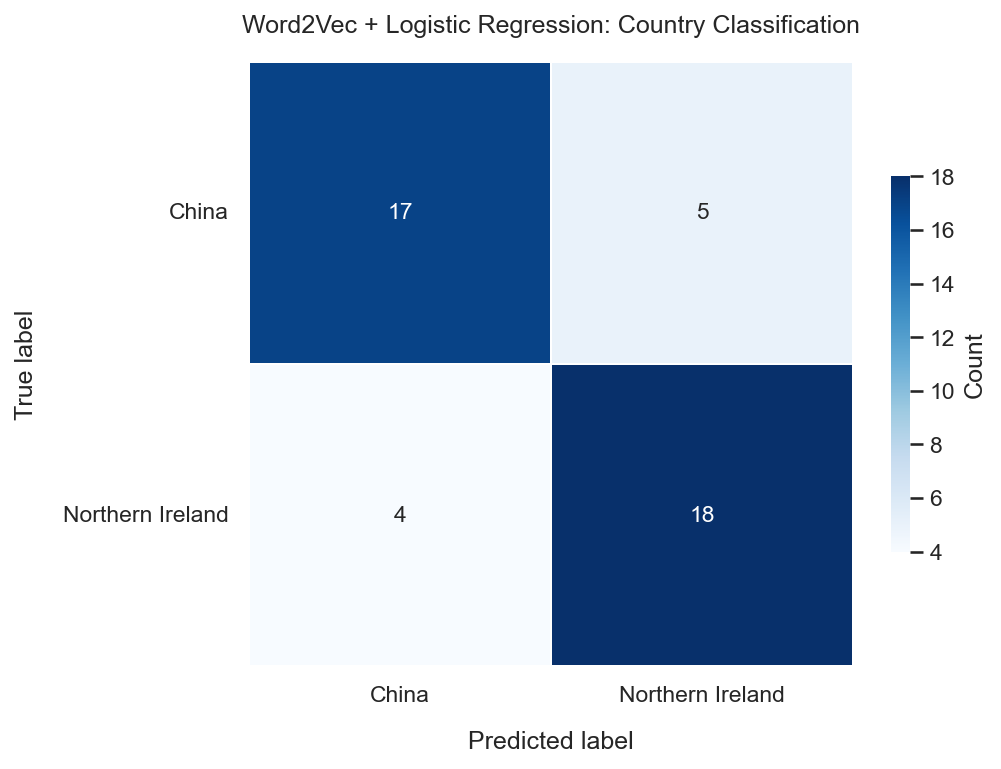

In [11]:
# Load and fit a logistic regression model with data standardisation 
logreg_model = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=3000, random_state=STUDENT_SEED))])
logreg_model.fit(X_w2v[country_splits["train"]], y_country[country_splits["train"]])

# Make predictions on the fitted model and capture accuracy and F1 score
w2v_test_pred = logreg_model.predict(X_w2v[country_splits["test"]])
w2v_metrics = {
    "model": "word2vec",
    "accuracy": accuracy_score(y_country[country_splits["test"]], w2v_test_pred),
    "macro_f1": f1_score(y_country[country_splits["test"]], w2v_test_pred, average="macro"),
}

# Display overall results, classification report and confusion matrix
print(w2v_metrics)
print(classification_report(y_country[country_splits["test"]], w2v_test_pred, target_names=COUNTRY_NAMES))
show_confusion_matrix(
    y_country[country_splits["test"]],
    w2v_test_pred,
    labels=COUNTRY_NAMES,
    title="Word2Vec + Logistic Regression: Country Classification")

### 1.2 BERT

In BERT, a special `[CLS]` token is inserted at the beginning of each sequence and represents the meaning of a sentence.<sup>4</sup> We follow common practice by using the hidden state of this token and adding a linear layer as a classification head.<sup>4</sup> A dropout layer of 0.2 is applied to the classification head as regularisation, randomly "turning off" 20% of neurons to discourage overly high weights.<sup>5</sup> The logits are output from the classification head and input into the cross-entropy loss function.

Stories are tokenised and truncated to BERT's max length of 512 tokens. We could have used sliding windows to process the full story, but manual inspection suggested enough predictive signals exist in the first half. Later testing with ModernBERT's longer context confirmed that processing the full story led to no improvement in accuracy.

The learning curve over 3 epochs was fast and stable, with no signs of overfitting.

Key aspects of the model architecture are presented in a diagram below. It highlights the four core parts of the architecture: 

1. Wordpiece tokenisation is applied to the data and splits up the text into subword tokens. 
2. The tokenised data is passed through three embedding layers: vector embeddings for the tokens themselves, position embeddings, and sentence embeddings (for BERT's sentence prediction task). The embeddings are 768-dimensional vectors per token.
3. The embeddings are passed into transformer layer, which consists of a multi-head self-attention block (to dynamically update token embeddings based on the surrounding context), which is added to a residual block with LayerNorm, then a feed-forward network with a GELU activation, which is again added to a residual block. The residual block guards against vanishing gradients. There are 12x of these blocks which are run in parallel and later stacked together.
4. The classification head is added and in this case applied directly to the `[CLS]` token only. Dropout is applied, the resulting vector is passed through a linear layer and outputs the logits. They are converted into probabilities with the softmax function and this is passed into the cross-entropy loss function. The sigmoid function could be used here instead for the binary classification task, but the same BERT architecture is used in section 2.1 to predict sentiment, so the softmax function can efficiently accommodate both.

Note: a more basic, hand-drawn model architecture is saved in appendix 2 in case a Mermaid diagram is too polished to indicate my own understanding.

![image](base_bert_architecture.png)


In [12]:
# Load a torch Dataset with tokenised text and truncation on max length  

class TextClassificationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        """Store text samples and labels for tokenized batching."""
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        """Return the number of dataset samples."""
        return len(self.texts)

    def __getitem__(self, idx):
        """Tokenize one sample and return tensors."""
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# Load BERT with a classifier head on top, return the loss and logits 

class BareBertClassifier(torch.nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.2):
        """Initialize a BERT encoder with a linear classifier head."""
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = torch.nn.Dropout(dropout)
        self.classifier = torch.nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        """Run a forward pass and return loss and logits."""
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        cls_state = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(self.dropout(cls_state))
        loss = None
        loss = torch.nn.functional.cross_entropy(logits, labels)
        return {"loss": loss, "logits": logits}

In [13]:
# Build data loaders
def build_text_classification_loaders(train_texts, train_labels, val_texts, val_labels, test_texts, test_labels, tokenizer, max_length, train_batch_size=4, eval_batch_size=8):
    """Build train, validation, and test data loaders."""
    train_ds = TextClassificationDataset(train_texts, train_labels, tokenizer, max_length)
    val_ds = TextClassificationDataset(val_texts, val_labels, tokenizer, max_length)
    test_ds = TextClassificationDataset(test_texts, test_labels, tokenizer, max_length)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=train_batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=eval_batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=eval_batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

#  Run a forward pass and capture the key results on a specific model
def evaluate_classifier(model, dataloader):
    """Evaluate a classifier and return aggregate metrics."""
    model.eval()
    all_preds, all_labels = [], []
    running_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            running_loss += outputs["loss"].item()
            preds = outputs["logits"].argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch["labels"].cpu().numpy())
    return {
        "loss": running_loss / len(dataloader),
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "preds": np.array(all_preds),
        "labels": np.array(all_labels),
    }

# Train the classifier: run a forward pass, capture the loss, 
# calculate the gradients with backprop, optimise on a schedule 
# and store the results in a history df and model state dict 
def train_classifier(model, train_loader, val_loader, epochs=3, lr=2e-5, patience=None):
    """Train the classifier with optional early stopping."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = epochs * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, total_steps / 10),
        num_training_steps=total_steps,
    )
    best_state = None
    best_val_loss = float("inf")
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs["loss"]
            loss.backward()
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        val_metrics = evaluate_classifier(model, val_loader)
        record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
        }
        history.append(record)
        print(record)

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if patience is not None and wait >= patience:
                print(f"Early stopping triggered after epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return pd.DataFrame(history)

# Combine in a single pipeline: create data loaders, train model, save and report results
def text_classifier_pipeline(model, tokenizer, train_df, val_df, test_df, text_col, label_col, label_names, max_length, epochs=3, lr=2e-5, patience=None, train_batch_size=4, eval_batch_size=8, confusion_title="Test confusion matrix"):
    """Train, evaluate, and report a full text classification pipeline run."""
    train_loader, val_loader, test_loader = build_text_classification_loaders(
        train_df[text_col],
        train_df[label_col],
        val_df[text_col],
        val_df[label_col],
        test_df[text_col],
        test_df[label_col],
        tokenizer,
        max_length,
        train_batch_size=train_batch_size,
        eval_batch_size=eval_batch_size,
    )

    history = train_classifier(
        model,
        train_loader,
        val_loader,
        epochs=epochs,
        lr=lr,
        patience=patience,
    )

    test_metrics = evaluate_classifier(model, test_loader)
    
    print('\nTest Results:')
    print({k: v for k, v in test_metrics.items() if k not in {"preds", "labels"}})
    print(classification_report(test_metrics["labels"], test_metrics["preds"], target_names=label_names))
    show_confusion_matrix(
        test_metrics["labels"],
        test_metrics["preds"],
        labels=label_names,
        title=confusion_title,
    )

    history_and_test = {
        "history": history,
        "test_metrics": test_metrics
    }

    return history_and_test

In [14]:
# Load BERT tokenizer
BERT_MODEL_NAME = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

Token indices sequence length is longer than the specified maximum sequence length for this model (766 > 512). Running this sequence through the model will result in indexing errors


% of stories above BERT's 512 tokens: 100.00%


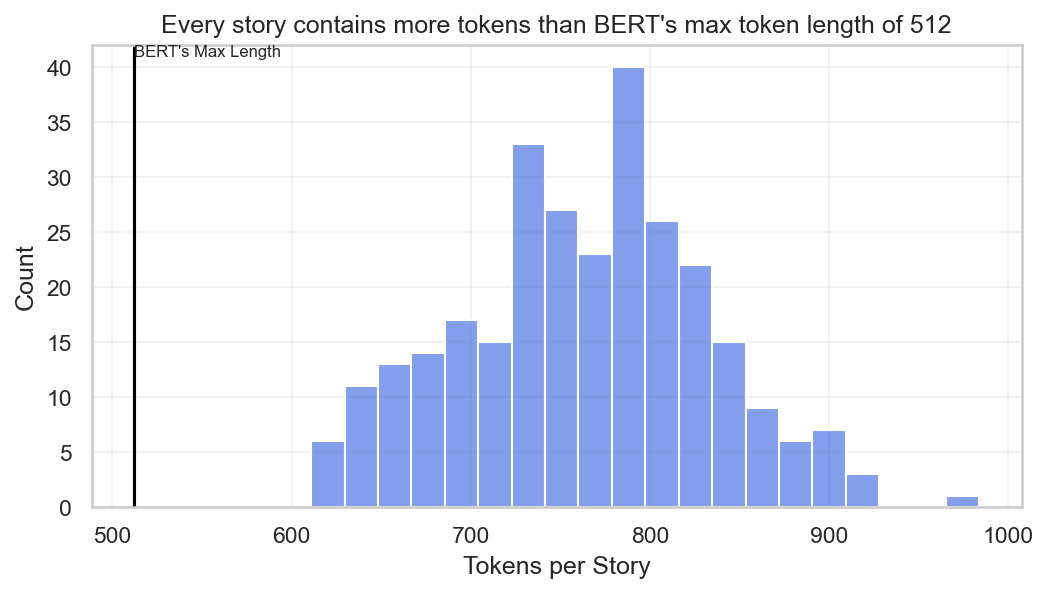

In [15]:
# Calculate token lengths of each story using BERT's tokenizer
bert_token_lengths = [len(bert_tokenizer(story, truncation=False)["input_ids"]) for story in country_df["story"]]

MAX_LENGTH_BERT = 512

# Plot the distribution of token lengths vs. BERT's 512-token limit
sns.histplot(bert_token_lengths, bins=20, color="#597ee3")
plt.axvline(512, color='black')
plt.text(MAX_LENGTH_BERT, 41, "BERT's Max Length", fontsize=8)
plt.xlabel("Tokens per Story")
plt.ylabel("Count")
plt.title("Every story contains more tokens than BERT's max token length of 512");

frac_above_512 = np.mean(np.array(bert_token_lengths) > MAX_LENGTH_BERT)

print(f"% of stories above BERT's 512 tokens: {frac_above_512:.2%}")

{'epoch': 1, 'train_loss': 0.6931211317286772, 'val_loss': 0.7957688271999359, 'val_accuracy': 0.5116279069767442, 'val_macro_f1': 0.37681159420289856}
{'epoch': 2, 'train_loss': 0.5579819509796068, 'val_loss': 0.6100830535093943, 'val_accuracy': 0.6976744186046512, 'val_macro_f1': 0.6721407624633431}
{'epoch': 3, 'train_loss': 0.23006448777867297, 'val_loss': 0.25233417625228566, 'val_accuracy': 0.9069767441860465, 'val_macro_f1': 0.9069264069264069}

Test Results:
{'loss': 0.32529230415821075, 'accuracy': 0.8863636363636364, 'macro_f1': 0.8858329008822003}
                  precision    recall  f1-score   support

           China       0.84      0.95      0.89        22
Northern Ireland       0.95      0.82      0.88        22

        accuracy                           0.89        44
       macro avg       0.89      0.89      0.89        44
    weighted avg       0.89      0.89      0.89        44



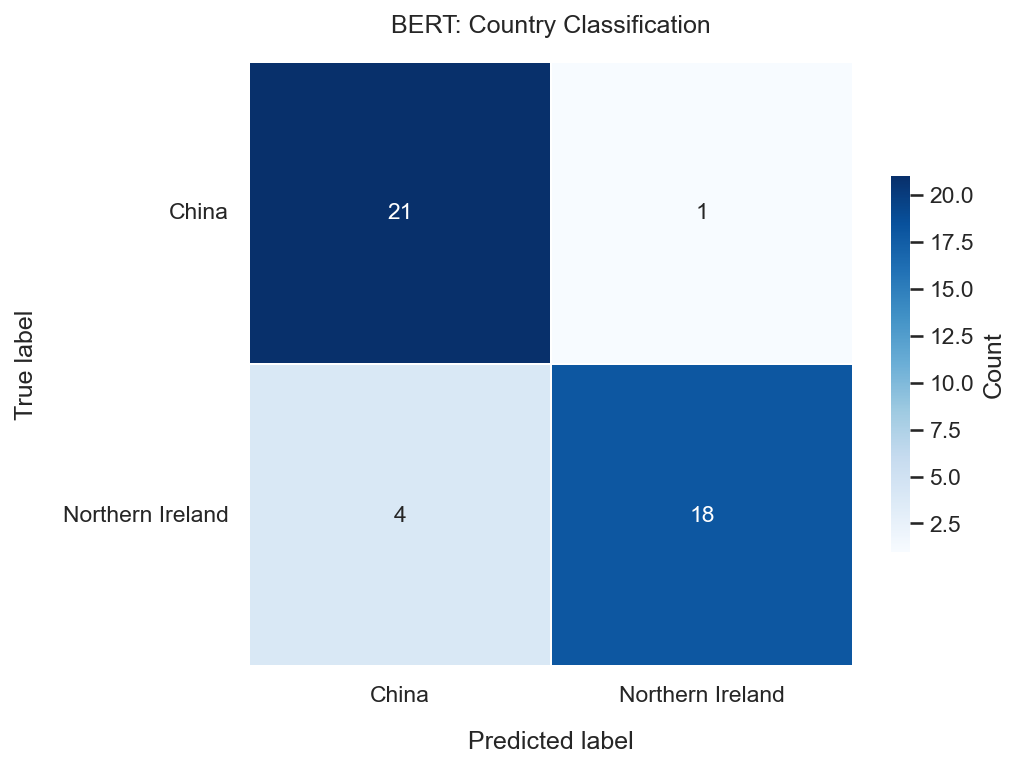

In [16]:
# Create train, test and val dfs, re-using indices defined in section 1.1
train_df = country_df.iloc[country_splits["train"]]
val_df = country_df.iloc[country_splits["val"]]
test_df = country_df.iloc[country_splits["test"]]

# Load BERT model
bare_bert = BareBertClassifier(BERT_MODEL_NAME, num_labels=len(COUNTRY_LABELS)).to(device)

# Run full pipeline
bare_bert_pipeline = text_classifier_pipeline(
    model=bare_bert,
    tokenizer=bert_tokenizer,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    text_col="story",
    label_col="label",
    label_names=COUNTRY_NAMES,
    max_length=MAX_LENGTH_BERT,
    epochs=3,
    lr=2e-5,
    confusion_title="BERT: Country Classification",
)

# Store key metrics from pipeline
bare_bert_history = bare_bert_pipeline["history"]
bare_bert_test = bare_bert_pipeline["test_metrics"]

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1
0,1,0.693121,0.795769,0.511628,0.376812
1,2,0.557982,0.610083,0.697674,0.672141
2,3,0.230064,0.252334,0.906977,0.906926


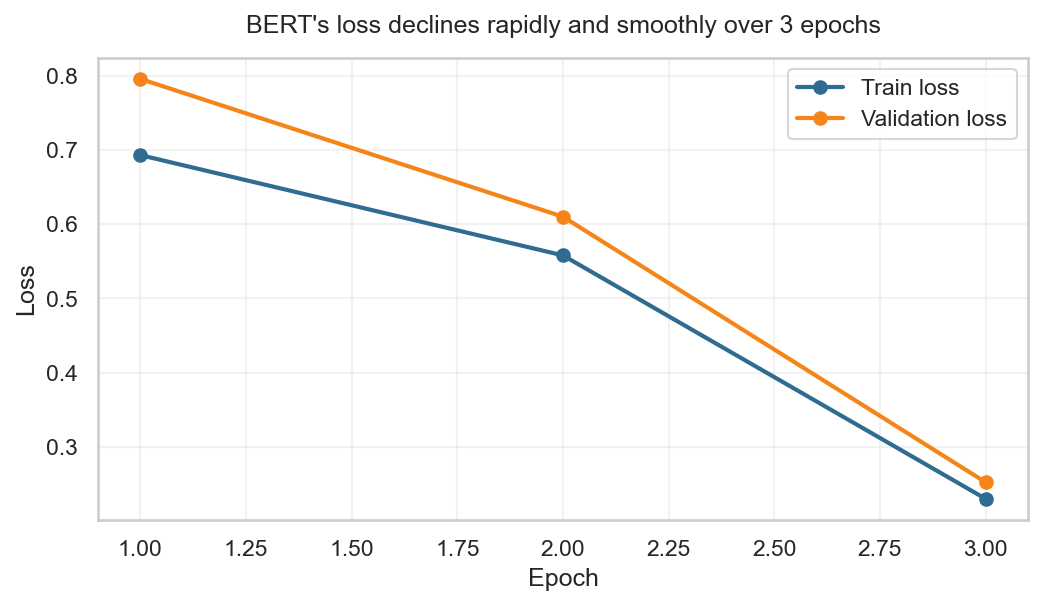

In [17]:
# Display summary stats and plot loss curves
display(bare_bert_history)
plot_loss_curves(bare_bert_history, "BERT's loss declines rapidly and smoothly over 3 epochs")

In [18]:
bare_bert

BareBertClassifier(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, ele

### 1.3 ModernBERT

ModernBERT followed the same setup as BERT, with the key difference being Hugging Face's `AutoModelForSequenceClassification` automatically adds the classification head and loss function.

In the default implementation ModernBERT has a dropout rate of 0.0 and catastrophically overfits, with validation loss increasing within 5 epochs. ModernBERT is a larger model with 30% more parameters and trained on a larger corpus of data, so it additional regularisation was applied:

- Through testing, a dropout rate of 0.5 produced a more stable learning curve and +10% test accuracy. A higher initial learning rate of 3e-5 produced better results too. 
- Early stopping would be triggered when the validation loss failed to decline for 3 consecutive epochs. In this instance early stopping was triggered after epoch 15.

Increasing `MAX_LENGTH` to 1024 showed no improvement, so it was aligned to BERT's 512 for clean comparisons. 

Despite these adjustments, all learning curves were less stable than BERT and showed signs of overfitting.

In [19]:
# Load ModernBERT tokenizer
MODERNBERT_MODEL_NAME = "answerdotai/ModernBERT-base"
modern_tokenizer = AutoTokenizer.from_pretrained(MODERNBERT_MODEL_NAME)

# Add a dropout rate of 0.5 to the classifier head of ModernBERT
config = AutoConfig.from_pretrained(MODERNBERT_MODEL_NAME, num_labels=2)
config.classifier_dropout = 0.5

MAX_LENGTH_MODERNBERT = 512  # Can do 1024 but significantly slower with no consistent improvement in performance

W0413 02:21:28.619000 20084 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'epoch': 1, 'train_loss': 0.8104007337607589, 'val_loss': 0.6900144666433334, 'val_accuracy': 0.5116279069767442, 'val_macro_f1': 0.49411764705882355}
{'epoch': 2, 'train_loss': 0.795000232610048, 'val_loss': 0.6810571054617564, 'val_accuracy': 0.5581395348837209, 'val_macro_f1': 0.5542825968357883}
{'epoch': 3, 'train_loss': 0.6777375539143881, 'val_loss': 0.7200691799322764, 'val_accuracy': 0.5813953488372093, 'val_macro_f1': 0.5793478260869566}
{'epoch': 4, 'train_loss': 0.6562629879689684, 'val_loss': 0.8406846721967062, 'val_accuracy': 0.5581395348837209, 'val_macro_f1': 0.542296918767507}
{'epoch': 5, 'train_loss': 0.6932661393109489, 'val_loss': 0.6482669115066528, 'val_accuracy': 0.5581395348837209, 'val_macro_f1': 0.5542825968357883}
{'epoch': 6, 'train_loss': 0.48259397523075925, 'val_loss': 0.5166397343079249, 'val_accuracy': 0.7209302325581395, 'val_macro_f1': 0.7013888888888888}
{'epoch': 7, 'train_loss': 0.3207448284853907, 'val_loss': 0.22932366157571474, 'val_accuracy'

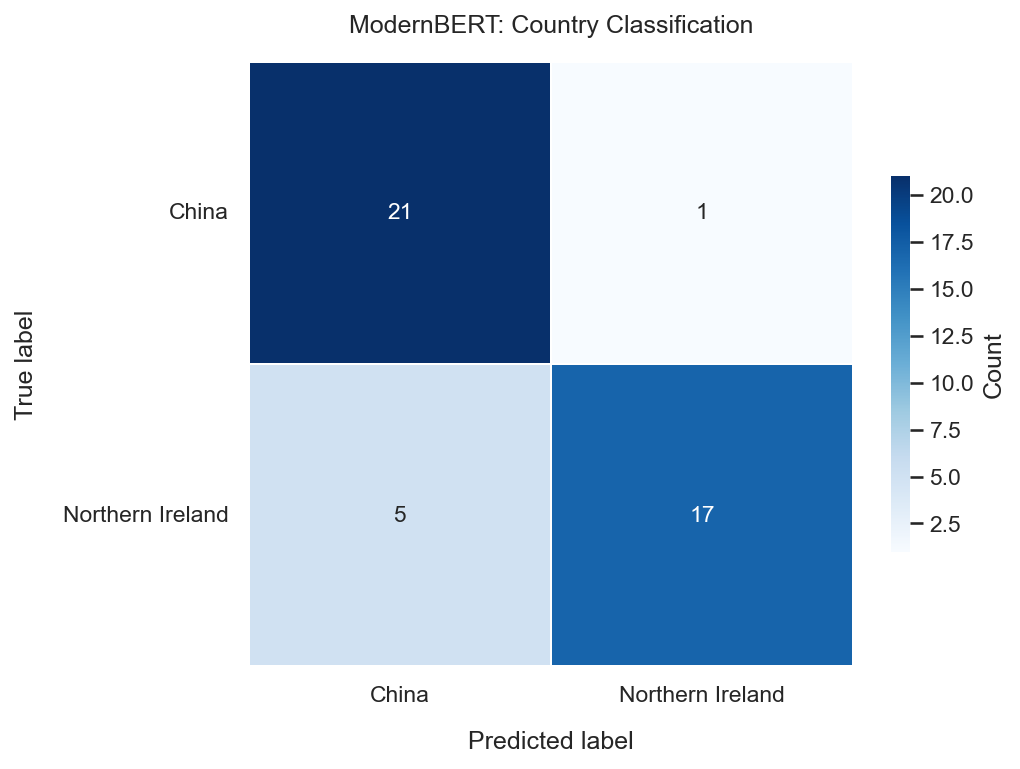

In [20]:
# Create copies of train, val and test dfs
modern_train_df = train_df[["story", "label"]].copy()
modern_val_df = val_df[["story", "label"]].copy()
modern_test_df = test_df[["story", "label"]].copy()

# Load ModernBERT model
modernbert = AutoModelForSequenceClassification.from_pretrained(
    MODERNBERT_MODEL_NAME,
    config=config
).to(device)

# Run full pipeline
modernbert_pipeline = text_classifier_pipeline(
    model=modernbert,
    tokenizer=modern_tokenizer,
    train_df=modern_train_df,
    val_df=modern_val_df,
    test_df=modern_test_df,
    text_col="story",
    label_col="label",
    label_names=COUNTRY_NAMES,
    max_length=MAX_LENGTH_MODERNBERT,
    epochs=15,
    lr=3e-5,
    patience=3, # use early stopping
    confusion_title="ModernBERT: Country Classification",
)

# Store key metrics from pipeline
modernbert_history = modernbert_pipeline["history"]
modernbert_test = modernbert_pipeline["test_metrics"]

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1
0,1,0.810401,0.690014,0.511628,0.494118
1,2,0.795000,0.681057,0.558140,0.554283
2,3,0.677738,0.720069,0.581395,0.579348
3,4,0.656263,0.840685,0.558140,0.542297
4,5,0.693266,0.648267,0.558140,0.554283
5,6,0.482594,0.516640,0.720930,0.701389
6,7,0.320745,0.229324,0.906977,0.905702
7,8,0.107705,0.191920,0.953488,0.953463
8,9,0.025664,0.151238,0.930233,0.930233
9,10,0.005395,0.128241,0.953488,0.953261


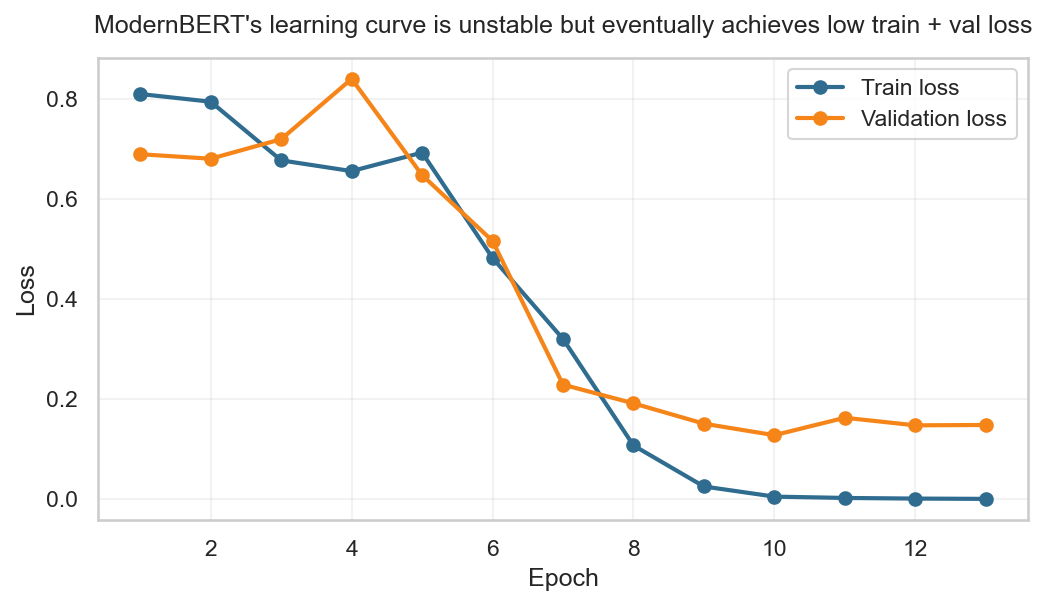

In [21]:
# Display summary stats and plot loss curves
display(modernbert_history)
plot_loss_curves(modernbert_history, "ModernBERT's learning curve is unstable but eventually achieves low train + val loss")

In [22]:
# Combine accuracy and F1 metrics from all three model runs to compare
section1_comparison = pd.DataFrame(
    [
        w2v_metrics,
        {
            "model": "bare_bert",
            "accuracy": bare_bert_test["accuracy"],
            "macro_f1": bare_bert_test["macro_f1"],
        },
        {
            "model": "modernbert",
            "accuracy": modernbert_test["accuracy"],
            "macro_f1": modernbert_test["macro_f1"],
        },
    ]
)

# Sort on F1 score and display results
section1_comparison = section1_comparison.sort_values("macro_f1", ascending=False)
section1_comparison

,model,accuracy,macro_f1
1,bare_bert,0.886364,0.885833
2,modernbert,0.863636,0.862500
0,word2vec,0.795455,0.795349


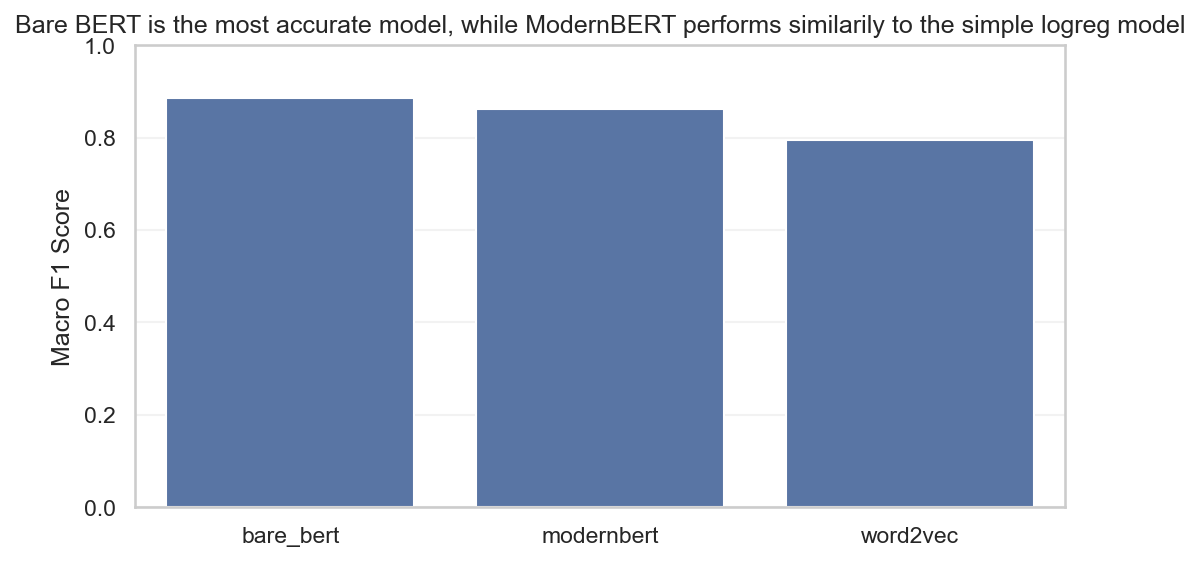

In [23]:
# Create a bar chart with the F1 score for each model
sns.barplot(data=section1_comparison, x="model", y="macro_f1", orient='v')
plt.title("Bare BERT is the most accurate model, while ModernBERT performs similarily to the simple logreg model")
plt.xlabel("")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1);

In [24]:
modernbert

ModernBertForSequenceClassification(
  (model): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (rotary_emb): ModernBertRotaryEmbedding()
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_features=768, bias=False)
        )
      

## 2. Sentiment and Emotion Analysis

This section uses zero-shot classification: we use models previously fine-tuned for sentiment and emotion tasks and perform inference on our dataset.<sup>6</sup> 

With no ground truth labels there is no clear way to determine a "correct" answer, and different models will produce different results. This is further complicated by the subjectivity of sentiment and emotion; a group of human evaluators would also disagree.<sup>7</sup> The focus is therefore on utility rather than correctness: relative differences between groups on the same model matter more than absolute scores.

### 2.1 Sentiment Analysis with RoBERTa

**RoBERTA Sentiment Probability Scores**

Theme | Positive | Negative |
--- | --- | --- | 
A dangerous voyage | 0.22 | 0.11 |
A mysterious conspiracy | 0.21 | 0.11 |
Love  | 0.24 | 0.07 |
Political rebellion | 0.20 | 0.11 |
Scientific discovery | 0.30 | 0.05 |

The dominant sentiment for all themes is `neutral` (61–65%). Scientific discovery is the most `positive` at 30%, with love trailing at 24%. The other three themes cluster together with identical `negative` scores of 11%. 

While this broadly aligns with intuition, sentiment is not a particularly discriminant tool. Even for single sentences with a median length of 26 words.

Before performing sentiment analysis we used BERT to predict `theme` from the last sentence alone. The F1 score was 0.39, but a direct comparison with the country classifier's 0.89 is misleading because a 5-class task has a lower random baseline (0.2 vs. 0.5). Cohen's Kappa adjusts for this:

$κ=\frac{​p_o​−p_e}{1−p_e}$​​

where $p_o$ is the observed value and $p_e$ is the expected value. 

Classification | Observed F1 Score | Expected F1 Score | Cohen's Kappa |
--- | --- | --- | --- | 
Country |  0.89 | 0.5 | 0.78 |
Theme |  0.39 | 0.2 | 0.24 |

This confirms the model performs relatively poorly at predicting `theme` from the last sentence, even with a larger training set (n=421 vs. n=201), validating that the signal:noise ratio between themes is low. 

Despite this, there is just enough signal to differentiate `scientific discovery` from the rest, as displayed in the boxplots. A Kruskal-Wallis test confirmed these differences are statistically significant at $p<0.05$. Kruskal-Wallis was used over ANOVA because the distributions are skewed.<sup>8</sup>

In [25]:
# Define theme labels   
THEME_NAMES = sorted(set(stories['theme']))
THEME_LABELS = {theme: idx for idx, theme in enumerate(THEME_NAMES)}

# Split stories on '\\n' and tokenise sentences with spaCy
def tokenise_sentences(text):
    """Split text into cleaned sentence strings."""
    sentences = []
    for line in text.strip().split('\\n'):
        line = line.strip()
        doc = nlp(line)
        sentences.extend([s.text.strip() for s in doc.sents])
    return sentences

# Extract the last sentence
def last_sentence(text):
    """Extract the final sentence"""
    sentences = tokenise_sentences(text)
    return sentences[-1].strip()

# Create a dataframe with the theme labels and the last sentence as columns
def make_theme_df(df):
    """Create a dataframe with theme labels and last sentences."""
    df = df.copy()
    df["label"] = df["theme"].map(THEME_LABELS)
    df["last_sentence"] = df["story"].map(last_sentence)
    df = df[['index', 'theme', 'label', 'story', 'last_sentence']]
    return df

# Generate classification label probabilities for the last sentence or averaged across all sentences
def classification_label_probs(texts, pipe, last_sentence=True, max_length=512, batch_size=32):
    """Return a DataFrame of per-label probabilities, one row per input text."""
    row_ids, all_sentences = [], []
    for i, text in enumerate(texts):
        sentences = [text] if last_sentence else tokenise_sentences(text)
        row_ids.extend([i] * len(sentences))
        all_sentences.extend(sentences)

    raw_data = pipe(all_sentences, truncation=True, max_length=max_length, batch_size=batch_size)
    probs = pd.DataFrame({data["label"]: data["score"] for data in raw} for raw in raw_data)
    probs["group_ids"] = row_ids
    return probs.groupby("group_ids").mean() # also tested max pooling

# Plot a heatmap of average multi-class probabilities (for sentiment or emotion)
def plot_theme_probability_heatmap(data, title, cmap="mako", fmt=".2f", annot=False, xlabel="", x_rotation=0):
    """Plot a heatmap of predicted label probabilities."""
    plt.figure(figsize=(8, 4))
    ax = sns.heatmap(
        data,
        cmap=cmap,
        annot=annot,
        fmt=fmt,
        linewidths=0.75,
        linecolor="white",
        yticklabels=wrapped_labels(data.index, width=18),
        cbar_kws={"shrink": 0.85, "label": "Probability"},
        annot_kws={"fontsize": 10} if annot else None,
    )
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.tick_params(axis="y", rotation=0)
    ax.tick_params(axis="x", rotation=x_rotation)
    return ax

# Plot a boxplot of multi-class probability distribution
def plot_theme_probability_boxplot(df, x, title):
    """Plot per-theme probability distributions as boxplots."""
    ax = sns.boxplot(
        data=df,
        y="theme",
        x=x,
        width=0.65,
        fliersize=3
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("")

In [26]:
# Make the theme_df dataframe with theme labels and the last sentence
theme_df = make_theme_df(stories)
theme_df.head(2)

,index,theme,label,story,last_sentence
0,0,love,2,"Whereas it is acknowledged, for the purposes o...","Hereinafter, readers shall construe the brass ..."
1,1,a dangerous voyage,0,I wake remembering salt in my hair and the sme...,"At dawn the sky bleeds ink into the sails, a m..."


In [27]:
# Calculate the median length (# of words) of the last sentence
theme_df["last_sentence"].str.split().apply(len).median()

np.float64(26.0)

In [28]:
# Split the dataframe into train, val and test indices and view distribution
theme_splits = build_train_val_test_indices(theme_df, "label", STUDENT_SEED)

with pd.option_context("display.max_colwidth", None):
    display(describe_split(theme_df, theme_splits, "theme"))

,split,size,distribution
0,train,421,"{'a dangerous voyage': 97, 'political rebellion': 90, 'love': 85, 'a mysterious conspiracy': 76, 'scientific discovery': 73}"
1,val,90,"{'a dangerous voyage': 20, 'political rebellion': 19, 'love': 19, 'a mysterious conspiracy': 16, 'scientific discovery': 16}"
2,test,91,"{'a dangerous voyage': 21, 'political rebellion': 20, 'love': 18, 'scientific discovery': 16, 'a mysterious conspiracy': 16}"


In [29]:
# Create train, val and test dataframes from the indices
theme_train_df = theme_df.iloc[theme_splits["train"]]
theme_val_df = theme_df.iloc[theme_splits["val"]]
theme_test_df = theme_df.iloc[theme_splits["test"]]

# Load the BERT tokenizer
theme_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

{'epoch': 1, 'train_loss': 1.6208965845827787, 'val_loss': 1.5819290777047474, 'val_accuracy': 0.26666666666666666, 'val_macro_f1': 0.2051910576514185}
{'epoch': 2, 'train_loss': 1.439330370921009, 'val_loss': 1.434512456258138, 'val_accuracy': 0.3888888888888889, 'val_macro_f1': 0.3585569985569985}
{'epoch': 3, 'train_loss': 1.0316736290477357, 'val_loss': 1.2750598788261414, 'val_accuracy': 0.4666666666666667, 'val_macro_f1': 0.439444903961033}

Test Results:
{'loss': 1.3068218032519023, 'accuracy': 0.42857142857142855, 'macro_f1': 0.4222263738392771}
                         precision    recall  f1-score   support

     a dangerous voyage       0.53      0.38      0.44        21
a mysterious conspiracy       0.45      0.56      0.50        16
                   love       0.42      0.56      0.48        18
    political rebellion       0.47      0.40      0.43        20
   scientific discovery       0.27      0.25      0.26        16

               accuracy                         

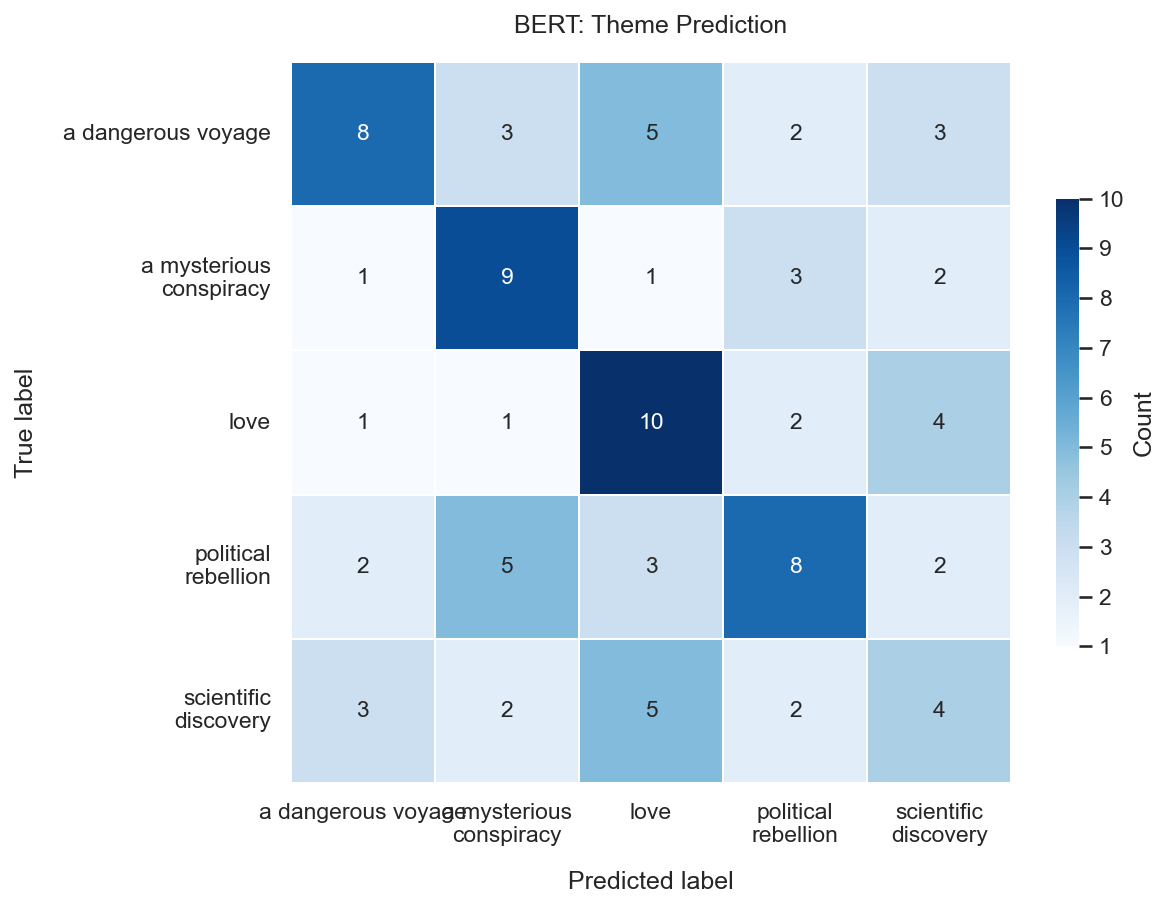

In [30]:
# Load the BERT model for Theme classification
theme_model = BareBertClassifier(BERT_MODEL_NAME, num_labels=len(THEME_LABELS)).to(device)

# Run full pipeline
theme_pipeline = text_classifier_pipeline(
    model=theme_model,
    tokenizer=theme_tokenizer,
    train_df=theme_train_df,
    val_df=theme_val_df,
    test_df=theme_test_df,
    text_col="last_sentence",
    label_col="label",
    label_names=THEME_NAMES,
    max_length=MAX_LENGTH_BERT,
    epochs=3,
    lr=2e-5,
    confusion_title="BERT: Theme Prediction",
)

# Store key metrics from pipeline
theme_history = theme_pipeline["history"]
theme_test = theme_pipeline["test_metrics"]

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1
0,1,1.620897,1.581929,0.266667,0.205191
1,2,1.439330,1.434512,0.388889,0.358557
2,3,1.031674,1.275060,0.466667,0.439445


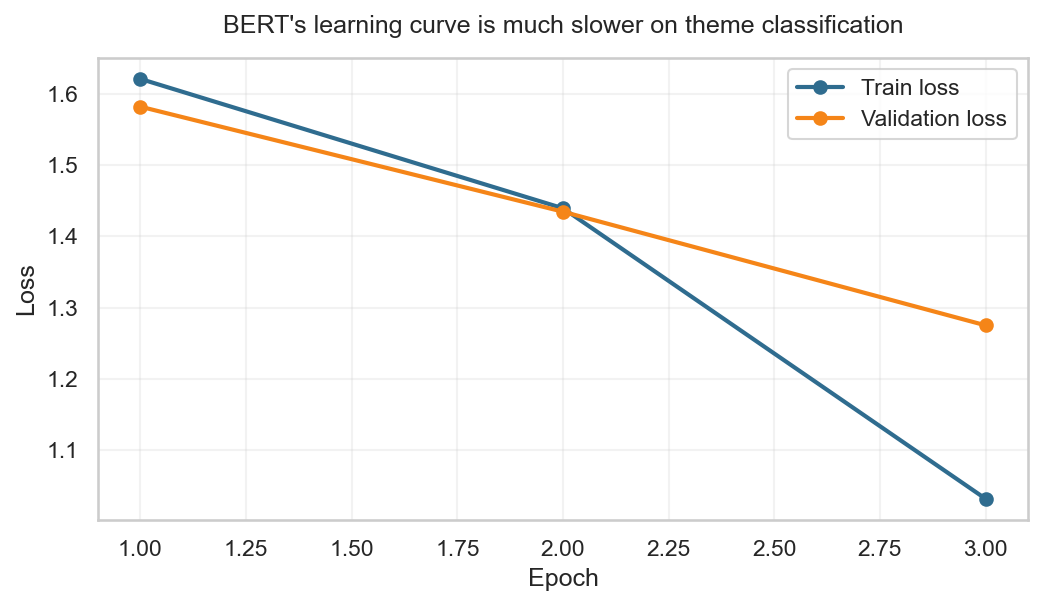

In [31]:
display(theme_history)
plot_loss_curves(theme_history, "BERT's learning curve is much slower on theme classification")

In [32]:
# Load RoBERTa sentiment model, run text classification pipeline 
# on the last sentence and display probabilities

ROBERTA_SENTIMENT = "cardiffnlp/twitter-roberta-base-sentiment-latest"
sentiment_pipe = pipeline(
    "text-classification", 
    model=ROBERTA_SENTIMENT,
    tokenizer=ROBERTA_SENTIMENT,
    top_k=None,
    device=device_index
)

sentiment_df = theme_df[["index", "theme"]].reset_index(drop=True).join(
    classification_label_probs(theme_df["last_sentence"], sentiment_pipe)
)
sentiment_df.head()

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


,index,theme,neutral,positive,negative
0,0,love,0.864421,0.106821,0.028759
1,1,a dangerous voyage,0.451597,0.035760,0.512642
2,2,a dangerous voyage,0.780947,0.188384,0.030669
3,3,political rebellion,0.172985,0.818240,0.008774
4,4,love,0.916074,0.071712,0.012214


<Axes: title={'center': 'Average sentiment of last sentence by theme'}, xlabel='Sentiment class'>

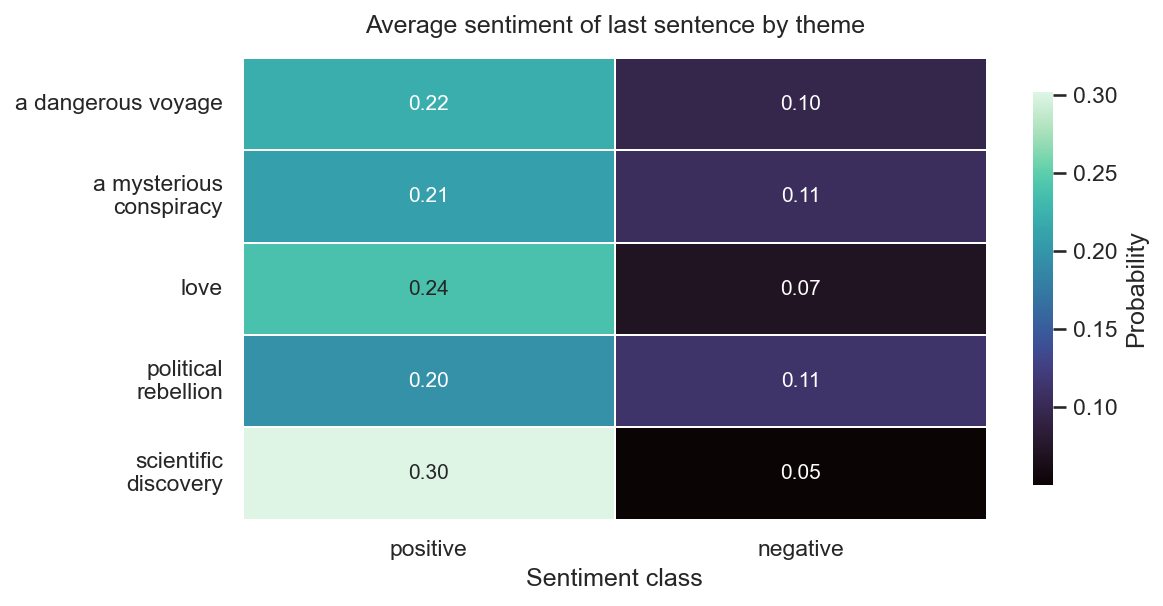

In [33]:
# Drop the dominant neutral sentiment columns and calculate the average pos/neg sentiment per theme
sentiment_by_theme = sentiment_df.drop(columns=["index", "neutral"]).groupby("theme").mean(numeric_only=True)

plot_theme_probability_heatmap(
    sentiment_by_theme,
    "Average sentiment of last sentence by theme",
    annot=True,
    xlabel="Sentiment class",
    x_rotation=0,
)

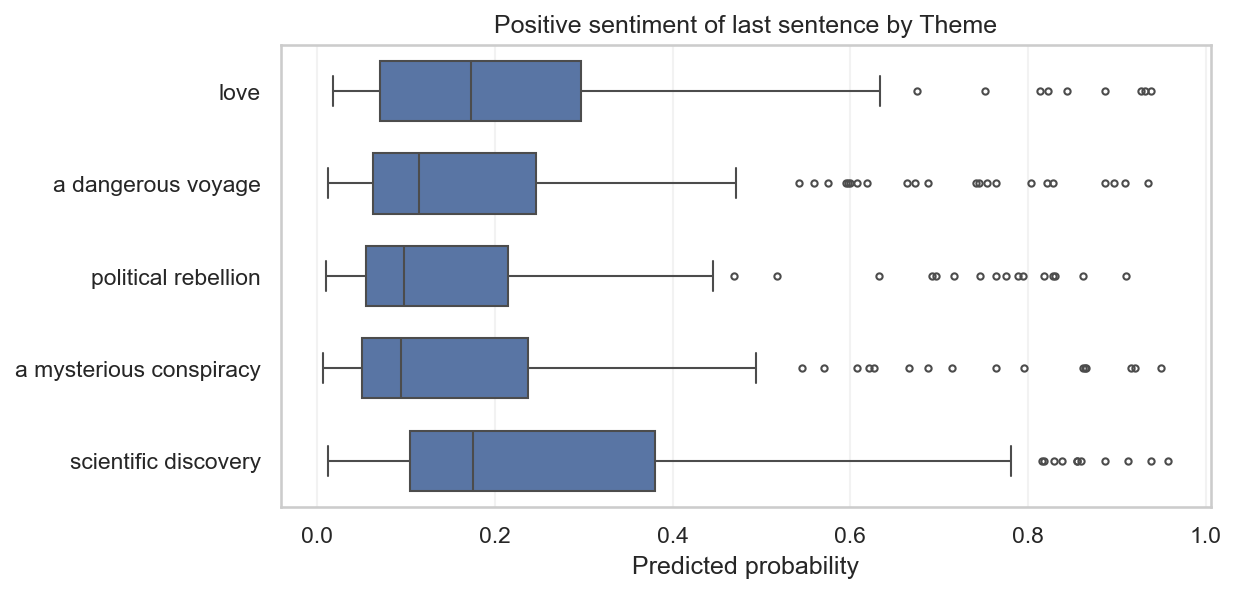

In [34]:
# Plot full distribution of the positive sentiment 
plot_theme_probability_boxplot(sentiment_df, 'positive', "Positive sentiment of last sentence by Theme")

In [35]:
# Run the Kruskal-Wallis test to identify 
grouped_positive = [group['positive'].to_numpy() for _, group in sentiment_df.groupby("theme")]
kw_stat, kw_p = stats.kruskal(*grouped_positive)
print(f"Kruskal-Wallis: H={kw_stat:.4f}, p={kw_p:.4g}")
if kw_p < 0.05:
    print('There is a statistically significant difference in sentiment between the themes at p < 0.05.')
else:
    print('There is no significant difference.')

Kruskal-Wallis: H=27.6425, p=1.474e-05
There is a statistically significant difference in sentiment between the themes at p < 0.05.


In [36]:
# Demonstrate the raw sentiment pipeline on an example story

example_story = "He set up instruments made of wood and glass, contraptions borrowed from classrooms and cobbled by necessity, and the valley became an amphitheater for a slow, ecstatic experiment; the lamp traced angles, the llama stood sentinel, and the scholar recorded every tremor of pattern with a discipline that felt like prayer. When at last a pattern resolved\u2014a consonance between sky, stone, and human rhythm\u2014he did not shout but smiled with the small, fierce joy of someone who has finally heard the key note in a long, muffled piece of music, the note that makes the rest fall into place. The canyon took this joy as it takes all small eruptions of feeling, storing it in the cool geometry of its walls, and in the morning light the scholar and his patient beast descended, carrying sketches and shards and a lamp dusted with the clean grit of discovery, leaving behind only the soft hoofprints that soon would be smoothed by wind and remembered only by stone."

pprint(example_story)
sentiment_pipe(example_story)


('He set up instruments made of wood and glass, contraptions borrowed from '
 'classrooms and cobbled by necessity, and the valley became an amphitheater '
 'for a slow, ecstatic experiment; the lamp traced angles, the llama stood '
 'sentinel, and the scholar recorded every tremor of pattern with a discipline '
 'that felt like prayer. When at last a pattern resolved—a consonance between '
 'sky, stone, and human rhythm—he did not shout but smiled with the small, '
 'fierce joy of someone who has finally heard the key note in a long, muffled '
 'piece of music, the note that makes the rest fall into place. The canyon '
 'took this joy as it takes all small eruptions of feeling, storing it in the '
 'cool geometry of its walls, and in the morning light the scholar and his '
 'patient beast descended, carrying sketches and shards and a lamp dusted with '
 'the clean grit of discovery, leaving behind only the soft hoofprints that '
 'soon would be smoothed by wind and remembered only by 

[[{'label': 'neutral', 'score': 0.6100456714630127},
  {'label': 'positive', 'score': 0.3739092946052551},
  {'label': 'negative', 'score': 0.016045033931732178}]]

### 2.2 Emotions Analysis with RoBERTa and DistilBERT

In this section we move beyond sentiment to emotion: from simple positive/negative sentiments to more nuanced emotions like `joy`, `fear`, and `surprise`.

Two emotion models were compared: RoBERTa Emotion [(source)](https://huggingface.co/cardiffnlp/twitter-roberta-base-emotion-multilabel-latest), chosen as a common baseline across students, and DistilBERT Emotion [(source)](https://huggingface.co/bhadresh-savani/distilbert-base-uncased-emotion), the most-downloaded emotion model on Hugging Face Hub. 

DistilBERT produces 6 emotion categories aligned with Ekman's basic emotions<sup>9</sup> while RoBERTa was finetuned on 11 emotions<sup>10</sup> based on Plutchik's wheel of emotions.<sup>11</sup>

Each model has its own baseline biases - `anger` skews high in DistilBERT, `joy` in RoBERTa - so absolute scores are not comparable. Instead we focus on the 6 common emotions and the relative differences within each model. 

For example, the overall mean `joy` score on RoBERTa was 0.34, while `love` stories scored 0.45 - the largest relative increase of any emotion. DistilBERT's absolute `joy` scores were lower across the board (0.29 mean), but `love` stories again showed the largest relative increase. This pattern holds across themes.

**RoBERTa and DistilBERT Emotion - Top Emotions per Model**

Theme | RoBERTa | DistilBERT |
--- | --- | --- | 
A dangerous voyage | Fear +0.03 | Fear +0.05 |
A mysterious conspiracy | Anger +0.03 | Fear +0.06 |
Love | Joy +0.11 | Joy +0.03 |
Political rebellion | Anger +0.03 | Anger +0.07 |
Scientific discovery | Joy +0.07 | Joy +0.07 |

The models agree on the most relevant emotion for 4/5 themes, disagreeing only on `a mysterious conspiracy` (RoBERTa: `anger`, DistilBERT: `fear`). This is consistent with the sentiment analysis: `love` and `scientific discovery` lean positive, the other three lean negative.

There are simplifying assumptions here: that a single emotion can describe an entire theme, and that mean-pooling sentence-level scores produces a meaningful story-level score. Stories arguably are better characterised by their emotional peaks than their baseline.<sup>12</sup> Max-pooling was tested but the key interpretations remained the same, it simply traded one bias (diluting emotional peaks) for another (ignoring emotional duration).

In [37]:
# Load the RoBERTa emotion model, run the pipeline on all sentences in the story and store the results

ROBERTA_EMOTION = "cardiffnlp/twitter-roberta-base-emotion-multilabel-latest"

roberta_emotion_pipe = pipeline(
    "text-classification",
    model=ROBERTA_EMOTION,
    tokenizer=ROBERTA_EMOTION,
    top_k=None,
    device=device_index,
)

roberta_emotion_df = stories[["index", "theme"]].reset_index(drop=True).join(
    classification_label_probs(stories["story"], roberta_emotion_pipe, last_sentence=False)
)

roberta_emotion_means = roberta_emotion_df.drop(columns=["index"]).groupby("theme").mean(numeric_only=True)
roberta_emotion_means

Device set to use cuda:0


,anticipation,optimism,joy,sadness,disgust,pessimism,surprise,anger,trust,fear,love
theme,,,,,,,,,,,
a dangerous voyage,0.331774,0.325277,0.314091,0.180667,0.131881,0.076609,0.042200,0.096443,0.054716,0.096674,0.034970
a mysterious conspiracy,0.385806,0.230755,0.250118,0.159422,0.173150,0.071579,0.066268,0.128531,0.050011,0.076722,0.031615
love,0.320351,0.381108,0.449703,0.178744,0.093583,0.059630,0.042130,0.067372,0.060489,0.041058,0.058726
political rebellion,0.358571,0.336061,0.283606,0.165313,0.161825,0.074421,0.042623,0.130497,0.059507,0.076861,0.028112
scientific discovery,0.392538,0.397599,0.411812,0.120619,0.093657,0.051333,0.052149,0.069397,0.070971,0.040719,0.041986


In [38]:
# Repeat for the DistilBERT emotion model

DISTILBERT_EMOTION = "bhadresh-savani/distilbert-base-uncased-emotion"

distilbert_emotion_pipe = pipeline(
    "text-classification",
    model=DISTILBERT_EMOTION,
    tokenizer=DISTILBERT_EMOTION,
    top_k=None,
    device=device_index,
)

distilbert_emotion_df = stories[["index", "theme"]].reset_index(drop=True).join(
    classification_label_probs(stories["story"], distilbert_emotion_pipe, last_sentence=False)
)

distilbert_emotion_means = distilbert_emotion_df.drop(columns=["index"]).groupby("theme").mean(numeric_only=True)
distilbert_emotion_means

Device set to use cuda:0


,joy,anger,fear,sadness,love,surprise
theme,,,,,,
a dangerous voyage,0.270012,0.317805,0.276968,0.099232,0.027365,0.008618
a mysterious conspiracy,0.243121,0.364098,0.286024,0.068471,0.025541,0.012745
love,0.317846,0.328585,0.196983,0.088891,0.060034,0.007661
political rebellion,0.269855,0.422580,0.177668,0.098808,0.023154,0.007934
scientific discovery,0.356546,0.323618,0.198855,0.061992,0.041099,0.017890


<Axes: title={'center': 'DistilBERT Emotion profile'}>

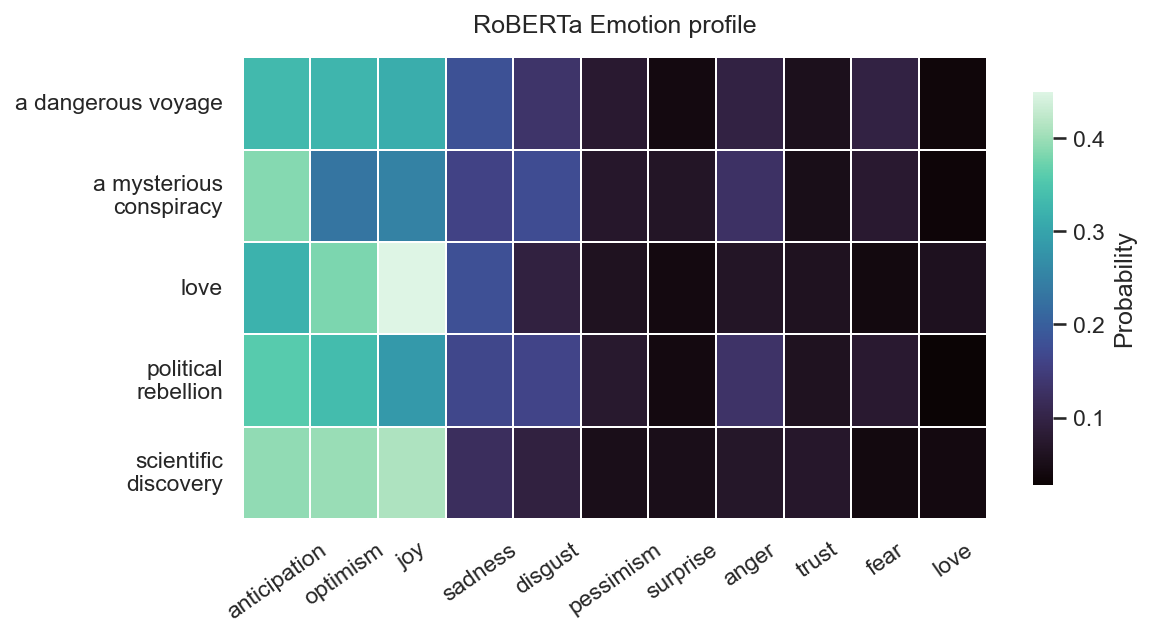

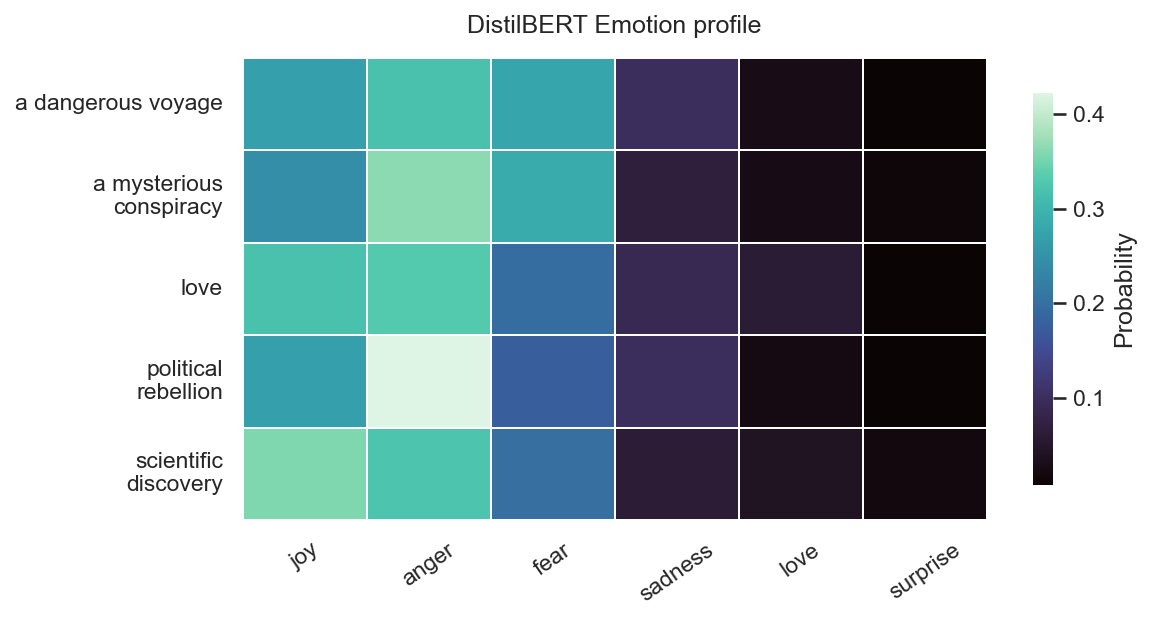

In [39]:
# Display heatmaps of the mean emotional probabilities per theme
# for both RoBERTa and DistilBERT for high-level comparison 

plot_theme_probability_heatmap(
    roberta_emotion_means,
    "RoBERTa Emotion profile",
    x_rotation=35,
)

plot_theme_probability_heatmap(
    distilbert_emotion_means,
    "DistilBERT Emotion profile",
    x_rotation=35,
)

In [40]:
# Capture the top-scoring emotion per theme for each models and compare them

top_emotion_df = pd.DataFrame({
    "theme": distilbert_emotion_means.index,
    "roberta_top_emotion": roberta_emotion_means.idxmax(axis=1).values,
    "roberta_top_prob": roberta_emotion_means.max(axis=1).values,
    "distilbert_top_emotion": distilbert_emotion_means.idxmax(axis=1).values,
    "distilbert_top_prob": distilbert_emotion_means.max(axis=1).values,
})

top_emotion_df

,theme,roberta_top_emotion,roberta_top_prob,distilbert_top_emotion,distilbert_top_prob
0,a dangerous voyage,anticipation,0.331774,anger,0.317805
1,a mysterious conspiracy,anticipation,0.385806,anger,0.364098
2,love,joy,0.449703,anger,0.328585
3,political rebellion,anticipation,0.358571,anger,0.422580
4,scientific discovery,joy,0.411812,joy,0.356546


In [41]:
# Calculate overall mean for each emotion 
roberta_overall_mean = roberta_emotion_df.drop(columns=["index", "theme"]).mean(numeric_only=True)
distilbert_overall_mean = distilbert_emotion_df.drop(columns=["index", "theme"]).mean(numeric_only=True)

print('Mean Emotion Score across all stories\n')
print(f'RoBERTA:\n{roberta_overall_mean}\n')
print(f'DistilBERT:\n{distilbert_overall_mean}')

Mean Emotion Score across all stories

RoBERTA:
anticipation    0.355493
optimism        0.334560
joy             0.340609
sadness         0.162702
disgust         0.131273
pessimism       0.067388
surprise        0.048330
anger           0.098888
trust           0.058903
fear            0.067818
love            0.038937
dtype: float64

DistilBERT:
joy         0.289941
anger       0.351760
fear        0.227480
sadness     0.085032
love        0.035151
surprise    0.010635
dtype: float64


In [42]:
# Calculate the difference
roberta_emotion_mean_diff = roberta_emotion_means - roberta_overall_mean
distilbert_emotion_mean_diff = distilbert_emotion_means - distilbert_overall_mean

<Axes: title={'center': 'Normalised DistilBERT Emotion profile'}>

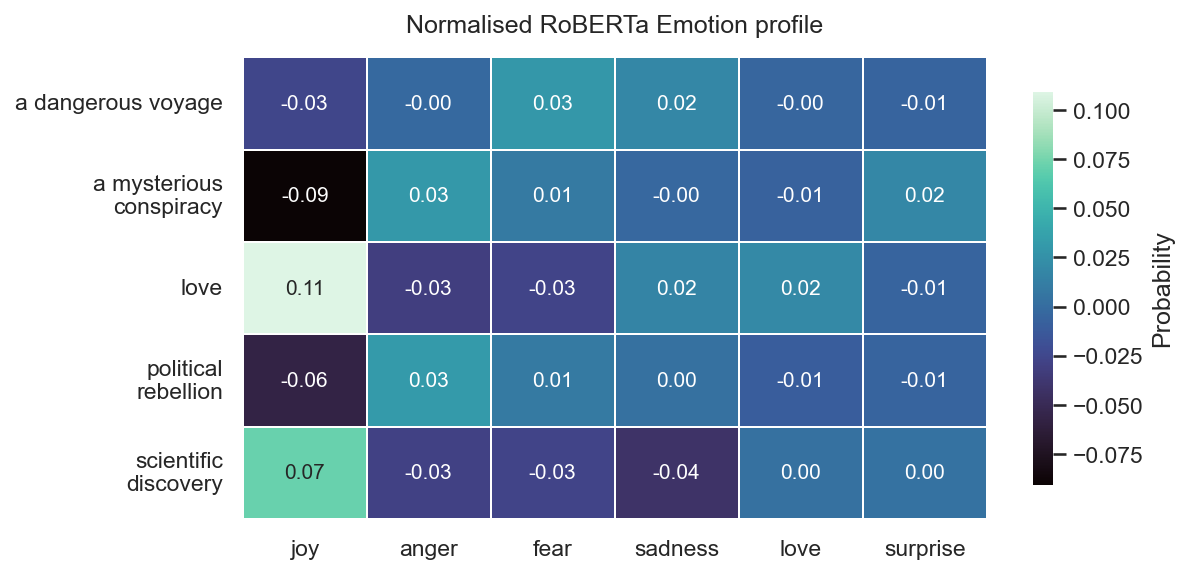

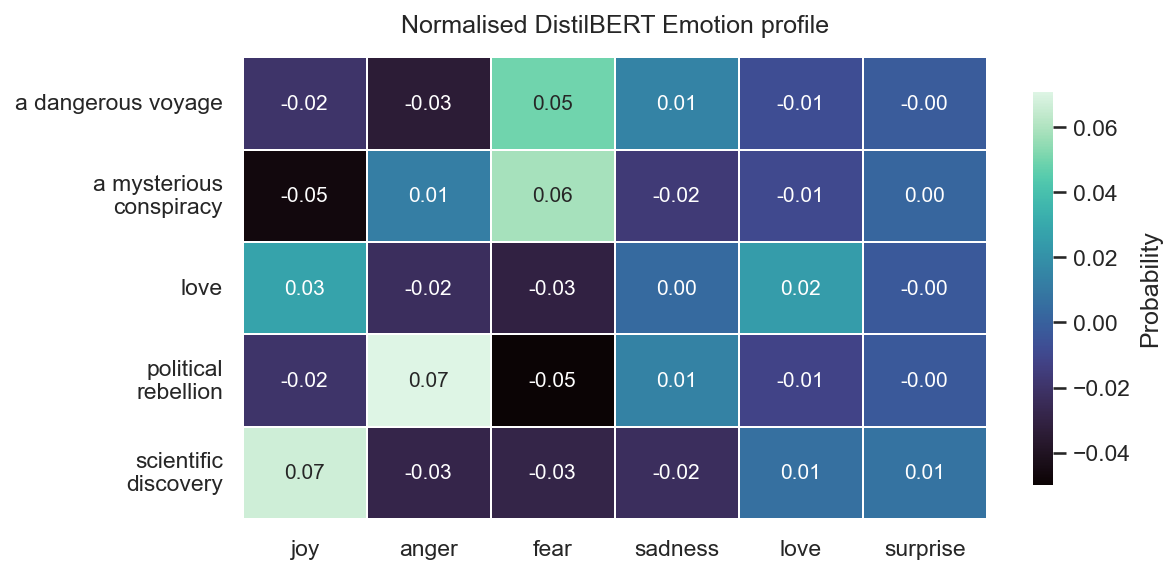

In [43]:
# Plot the differences / normalised emotional probabilities 
# for the emotions that appear in both models

plot_theme_probability_heatmap(
    roberta_emotion_mean_diff[distilbert_emotion_means.columns],
    "Normalised RoBERTa Emotion profile",
    annot=True,
)

plot_theme_probability_heatmap(
    distilbert_emotion_mean_diff,
    "Normalised DistilBERT Emotion profile",
    annot=True,
)

## 3. Question-Answering

Extractive question-answering aims to identify the span of text that contains the correct answer, rather than generating new text.<sup>13</sup> The goal is to predict token positions, which requires careful data preparation to deal with the "offset problem"<sup>14</sup>:

1. The correct answers are annotated in the stories with tags like `[START_Q1]`
2. These positions need to be extracted, the tags removed, and the new answer positions mapped to subword tokens post-tokenisation
3. For text larger than the model's context window, the text is processed in chunks with sliding windows while maintaining a record of which window each token belongs to

Evaluating QA predictions is also more nuanced than classification. There are degrees of correctness. Consider this example:

Question | Answer | Predicted Answer |
--- | --- | --- | 
What held the gate closed? | A rusted chain held the gate closed | A rusted chain |

Using exact match, this is wrong. Using common sense, it's entirely correct. One solution is the LLM-as-a-judge metric<sup>15</sup>, but we use a simpler approach of token-level F1 scores, which gives this answer a score of 0.6.

### 3.1 Extracting the Character Offset

The `stories_annotated.json` file contains stories with answer spans marked by e.g. `[START_Q1]`/`[END_Q1]` tags. The `process_annotated_story` function extracts the answer text and computes the character-level start position after removing the tags. The tags themselves shift all subsequent character positions, so stripping them before calculating the offset ensures the correct character and token offsets are utilised downstream. 

The output is a list of dictionaries in SQuAD format<sup>13</sup> containing the `id`, `question`, `context`, `answer_text`, `answer_start` and `style` fields.

The correctness of this function was verified by checking that context`[answer_start : answer_start + len(answer_text)]` matches the `answer_text`.

In [44]:
# Define the tags identifying the start and end of answers in the story
ANSWER_TAGS = ["[START_Q1]", "[END_Q1]", "[START_Q2]", "[END_Q2]"]

# Remove tags from the annotated story 
def remove_annotation_tags(text):
    """Remove answer annotation markers from story text."""
    for tag in ANSWER_TAGS:
        text = text.replace(tag, "")
    return text

# Extract the answer text and its start position
def extract_answer_and_start(annotated_text, start_tag, end_tag):
    """Extract tagged answer text and its cleaned start offset."""
    start_pos = annotated_text.index(start_tag)
    end_pos = annotated_text.index(end_tag)
    answer_text = annotated_text[start_pos + len(start_tag) : end_pos]
    prefix = annotated_text[:start_pos]
    prefix_clean = remove_annotation_tags(prefix)
    answer_start = len(prefix_clean)
    return answer_text, answer_start

# Create a dictionary of the key QA metadata: the question, context, answer text and start position for each story
def process_annotated_story(index):
    """Convert one annotated story row into QA examples."""
    row = stories_annotated.loc[index]
    annotated_story = row["annotated_story"]
    context = remove_annotation_tags(annotated_story)
    outputs = []

    for q_name, start_tag, end_tag in [
        ("q1", "[START_Q1]", "[END_Q1]"),
        ("q2", "[START_Q2]", "[END_Q2]"),
    ]:
        answer_text, answer_start = extract_answer_and_start(annotated_story, start_tag, end_tag)
        question = row[f"question{q_name[-1]}"] 
        story_qa_metadata = {
            "id": f"{index}_{q_name}",
            "question": question,
            "context": context,
            "answer_text": answer_text,
            "answer_start": answer_start,
            "style": row["style"],
        }
        outputs.append(story_qa_metadata)
    return outputs

In [45]:
# Display an example of the story's QA metadata

processed_story_example = process_annotated_story(0)
processed_story_example

[{'id': '0_q1',
  'question': 'What object did the Officeholder keep in the trunk of an overturned municipal bench?',
  'context': "Whereas it is acknowledged, for the purposes of narrative continuity and descriptive particularity, that the present account shall herein and hereinafter describe persons, places and occurrences occurring in the aftermath of societal cessation in the northern counties of the island, and whereas this account shall proceed in a manner of formal recital by reason of the Officeholder's proclivity for record-keeping, it is hereby recited as follows.\n\nWhereas the principal person, hereinafter referred to as the Officeholder, was vested with public trust by erstwhile assemblies and, notwithstanding the dissolution of many institutions, retained the trappings and rhetoric of governance; and whereas the Officeholder kept, in the trunk of an overturned municipal bench, a ledger of petitions and a brass instrument for summoning, it is further declared that these it

In [46]:
# Demonstrate that the answer text can be reconstructed by indexing the start and end positions

example_answer = processed_story_example[0]['answer_text']
example_answer_start = processed_story_example[0]['answer_start']
example_context = processed_story_example[0]['context']
example_reconstructed_answer = example_context[example_answer_start : example_answer_start + len(example_answer)]

print(example_answer)
print(example_reconstructed_answer)
print(f'\nMatching Answers: {example_answer == example_reconstructed_answer}')

Hereinafter the Officeholder kept a brass trombone, which he used in assemblies and at dusk to call the scattered to the square.
Hereinafter the Officeholder kept a brass trombone, which he used in assemblies and at dusk to call the scattered to the square.

Matching Answers: True


In [47]:
# Display the first 10 answer start values
# note that the first two start values match the assignment spec

first_five_offsets = []
for story_index in range(5):
    processed = process_annotated_story(story_index)
    for item in processed:
        first_five_offsets.append(item["answer_start"])
print("First 10 answer_start values for the first five stories:")
print(first_five_offsets)

First 10 answer_start values for the first five stories:
[914, 1975, 756, 2019, 2006, 1512, 2009, 2640, 1184, 655]


### 3.2 Baseline BERT SQuAD2 model

We use the Hugging Face `pipeline` with the `question-answering` task on bert-base-uncased-squad2<sup>16</sup>, a model finetuned on the SQuAD2 dataset<sup>13</sup>. 

The stories are longer than BERT's 512-token context window, so the pipeline processes them using sliding windows with a `stride` parameter. Each window overlaps with the previous one to ensure answer spans that fall on window boundaries are still captured. The `pipeline` returns the highest-confidence answer across all windows for each question.

The baseline results per writing style are:

Style | Token F1 Score |
--- | --- | 
For Children | 0.44 |
Hard-Boiled | 0.42 |
Descriptive | 0.29 |

The model performs substantially worse on `descriptive` stories, which contain more syntactically complex language, longer-distance dependencies, and simply longer answers. 

The median answer length for hard-boiled and for children stories was ~50 tokens, while descriptive stories exceeded 100. The token F1 score declined monotonically with answer length: from 0.5 for answers under 20 tokens to 0.2 for answers over 100 tokens.

One explanation for the relatively poor performance overall is that the model was trained on Wikipedia articles<sup>13</sup>, which is stylistically different to fiction prose found in short stories. AI-generated stories likely add a further dimension of difference.

In [48]:
# Filter the annotated dataframe on the three key styles 
def build_qa_examples_from_annotations(annotated_df):
    """Build QA examples from annotated stories by style."""
    style_subset = annotated_df[annotated_df["style"].isin(["descriptive", "hard-boiled", "for children"])]
    stories_qa_metadata = []
    for story_index in style_subset["index"]:
        stories_qa_metadata.extend(process_annotated_story(story_index))
    return pd.DataFrame(stories_qa_metadata)

# Remove punctuation to improve the accuracy of 
def strip_punct(text):
    "Remove punctuation from text"
    return text.translate(str.maketrans('', '', string.punctuation))

# Calculate the F1 score for matching tokens using basic word splitting and punctuation striping
def token_f1_score(prediction, ground_truth):
    """Compute token-level F1 overlap between prediction and truth, removing punctuation."""  
    pred_tokens = strip_punct(prediction).split()
    ground_truth_tokens = strip_punct(ground_truth).split()
    common = Counter(pred_tokens) & Counter(ground_truth_tokens)
    overlap = sum(common.values())
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_tokens)
    recall = overlap / len(ground_truth_tokens)
    return 2 * (precision * recall) / (precision + recall)

# Run a QA pipeline, generate predictions and present the results with relevant context
def generate_qa_predictions(pipeline, dataset):
    """Generate QA predictions and aggregate evaluation metrics."""
    preds = []
    for example in dataset:
        pred = pipeline(question=example["question"], context=example["context"])
        preds.append(
            {
                "id": example["id"],
                "style": example["style"],
                "question": example["question"],
                "ground_truth_answer": example["answer_text"],
                "predicted_answer": pred["answer"],
                "model_score": pred["score"],
                "token_f1": token_f1_score(pred["answer"], example["answer_text"]),
            }
        )

    qa_results = pd.DataFrame(preds)
    qa_results['answer_length'] = qa_results['ground_truth_answer'].str.len()

    overall_qa_metrics = {
    "token_f1": qa_results["token_f1"].mean(),
    "mean_model_score": qa_results["model_score"].mean(),
    }
    
    qa_by_style = (
        qa_results
        .groupby("style")[["token_f1", "model_score"]]
        .mean()
        .sort_values("token_f1", ascending=False)
    )

    return qa_results, overall_qa_metrics, qa_by_style

# Bin the answer length and plot the mean token f1 score to show the relationship
def plot_token_f1_vs_answer_length_bin(qa_results, title):
    """Plots the mean token F1 score by binned answer length for the provided QA results DataFrame."""
    # Bin answer lengths
    bin_edges = [0, 20, 50, 100, 400]
    bin_labels = [f"{bin_edges[i]}–{bin_edges[i+1]-1}" for i in range(len(bin_edges)-1)]
    qa_results = qa_results.copy()
    qa_results['answer_length_bin'] = pd.cut(
        qa_results['answer_length'], bins=bin_edges, labels=bin_labels, include_lowest=True
    )

    # Calculate mean of token_f1 for each bin
    binned_stats = qa_results.groupby('answer_length_bin')['token_f1'].mean().reset_index()
    binned_stats = binned_stats.rename(columns={'token_f1': 'mean'})

    plt.figure(figsize=(12,6))
    sns.barplot(data=binned_stats, x="answer_length_bin", y="mean")
    plt.title(title)
    plt.xlabel("Answer length bin")
    plt.ylabel("Mean Token F1")
    plt.xticks(rotation=30)
    plt.tight_layout()

In [49]:
# Create the QA examples dataframe and display it

qa_df = build_qa_examples_from_annotations(stories_annotated)
qa_df.head()

,id,question,context,answer_text,answer_start,style
0,3_q1,Where did she hide the message?,"Beyond the frozen curve of a great river, bene...",She hid the tiny gilded slip of paper inside t...,2009,descriptive
1,3_q2,What did he do at the parapet?,"Beyond the frozen curve of a great river, bene...",He rolled his battered wheelchair to the parap...,2640,descriptive
2,5_q1,What held the gate closed?,He kept his office lights on until dawn. The s...,A rusted chain held the gate closed.,1266,hard-boiled
3,5_q2,Where did he keep the kite?,He kept his office lights on until dawn. The s...,He kept the kite in a drawer under the files.,660,hard-boiled
4,8_q1,What did he find half-buried beneath the sands...,He walked among the ruins like a man moving th...,He found a rake half-buried beneath the sandst...,1177,descriptive


In [50]:
# Convert the dataframe into a Hugging Face dataset and display it

qa_dataset = Dataset.from_pandas(qa_df[["id", "question", "context", "answer_text", "answer_start", "style"]], preserve_index=False)
print(qa_dataset)

Dataset({
    features: ['id', 'question', 'context', 'answer_text', 'answer_start', 'style'],
    num_rows: 648
})


In [51]:
# Run the QA pipeline for the SQuAD2 model, generate the predictions and save the results

QA_MODEL = "deepset/bert-base-uncased-squad2"
qa_pipe = pipeline(
    "question-answering", 
    model=QA_MODEL, 
    tokenizer=QA_MODEL, 
    device=device_index)

qa_results, overall_qa_metrics, qa_by_style = generate_qa_predictions(qa_pipe, qa_dataset)

qa_results.head()

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,id,style,question,ground_truth_answer,predicted_answer,model_score,token_f1,answer_length
0,3_q1,descriptive,Where did she hide the message?,She hid the tiny gilded slip of paper inside t...,inside the steaming berry pie,0.818337,0.333333,133
1,3_q2,descriptive,What did he do at the parapet?,He rolled his battered wheelchair to the parap...,rolled his battered wheelchair,1.644943,0.275862,147
2,5_q1,hard-boiled,What held the gate closed?,A rusted chain held the gate closed.,A rusted chain,1.457155,0.600000,36
3,5_q2,hard-boiled,Where did he keep the kite?,He kept the kite in a drawer under the files.,a drawer under the files,0.827918,0.666667,45
4,8_q1,descriptive,What did he find half-buried beneath the sands...,He found a rake half-buried beneath the sandst...,a rake,0.749194,0.210526,95


In [52]:
# Display overall results and results aggregated by Style

print("Overall zero-shot QA metrics:", overall_qa_metrics)
qa_by_style

Overall zero-shot QA metrics: {'token_f1': np.float64(0.3881263324382656), 'mean_model_score': np.float64(0.7613887641353885)}


,token_f1,model_score
style,,
for children,0.444767,0.777119
hard-boiled,0.422483,0.668340
descriptive,0.287365,0.829024


Text(0, 0.5, '')

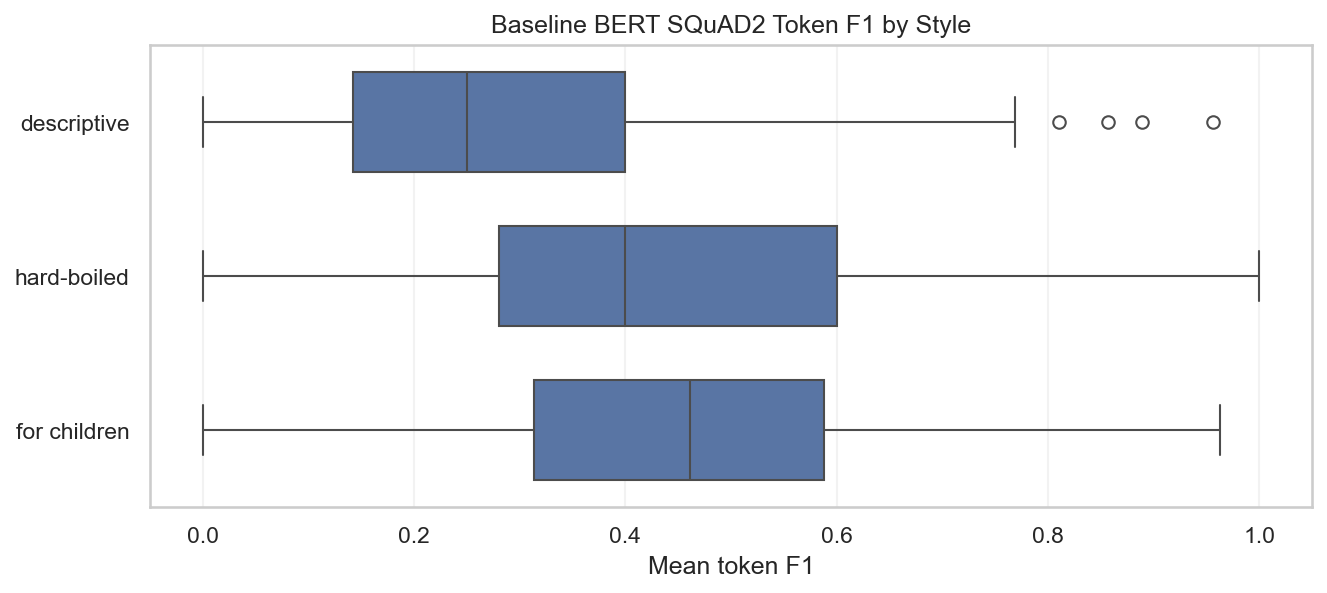

In [53]:
# Display the Token F1 per story distribution by Style

plt.figure(figsize=(10, 4))
sns.boxplot(data=qa_results, y="style", x="token_f1", 
        width=0.65)
plt.title("Baseline BERT SQuAD2 Token F1 by Style")
plt.xlabel("Mean token F1")
plt.ylabel("")

In [54]:
# Display the best examples
qa_results.sort_values("token_f1", ascending=False).head(5)

,id,style,question,ground_truth_answer,predicted_answer,model_score,token_f1,answer_length
467,440_q2,hard-boiled,What happened to the bookcase?,The bookcase swung open on a timer.,The bookcase swung open on a timer,0.556371,1.000000,35
581,551_q2,for children,What did Mika do after finding the bird?,Mika wrapped the bird in the old brown cloak a...,wrapped the bird in the old brown cloak and hu...,0.541982,0.962963,68
636,593_q1,descriptive,What did she do with the brass nut?,She tightened the brass nut with the pad of a ...,tightened the brass nut with the pad of a trem...,0.484470,0.956522,63
295,274_q2,for children,What did she do with the buckle?,She tightened the old buckle on her pack and k...,tightened the old buckle on her pack and kept ...,0.491953,0.952381,56
389,362_q2,for children,What did Maya do with the wheelchair?,Maya pushed the wheelchair slowly down the gar...,pushed the wheelchair slowly down the garden path,1.340342,0.941176,55


In [55]:
# Display the worst examples
qa_results.sort_values("token_f1", ascending=True).head(5)

,id,style,question,ground_truth_answer,predicted_answer,model_score,token_f1,answer_length
635,592_q2,hard-boiled,What sound followed them across the ice?,A nightingale sang once and then stopped.,dogs howling,0.786510,0.0,41
631,585_q2,hard-boiled,Where did the meeting take place for the escape?,The boat waited at the frozen pier.,basements,0.002471,0.0,35
51,54_q2,hard-boiled,What did the train carry?,The train carried medicine to the camps.,letters and grief,0.459576,0.0,40
342,317_q1,for children,What did Maya find in the little metal tin?,In the little metal tin of sardines there was ...,fish,0.775672,0.0,84
364,341_q1,hard-boiled,What did she do with the map and the briefcase?,She folded the map into silence and locked the...,walked away,1.155417,0.0,57


Text(0, 0.5, '')

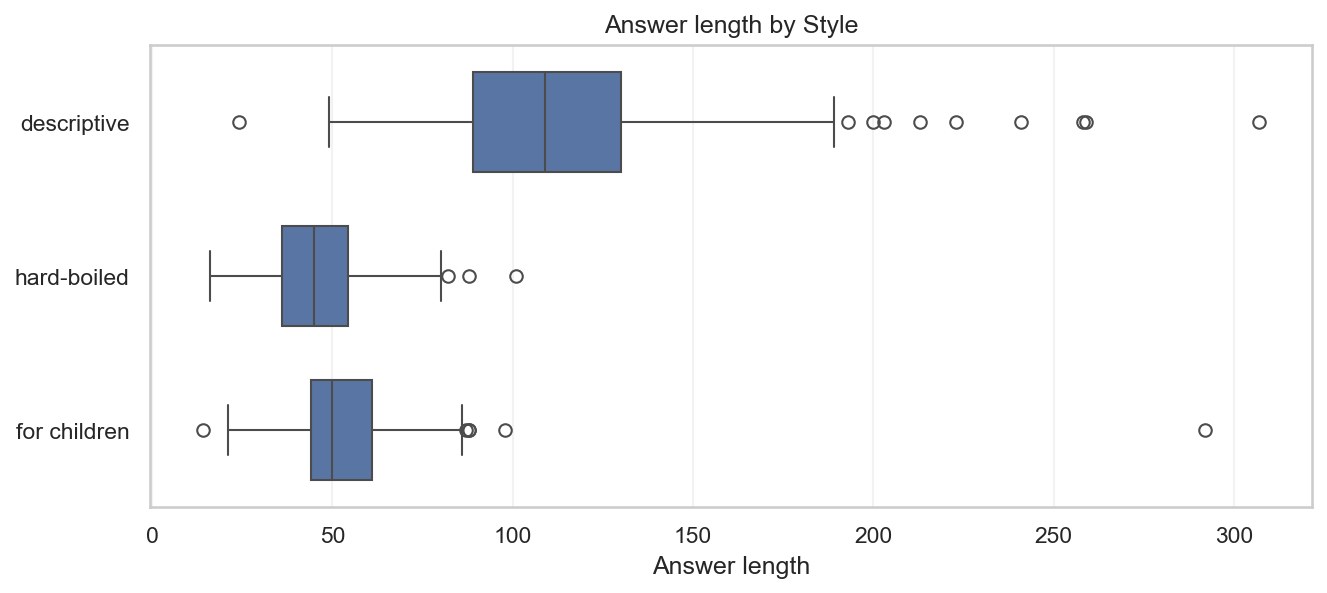

In [56]:
# Display the distribution of Answer Lengths per story by Style

plt.figure(figsize=(10, 4))
sns.boxplot(data=qa_results, y="style", x="answer_length", 
        width=0.65)
plt.title("Answer length by Style")
plt.xlabel("Answer length")
plt.ylabel("")

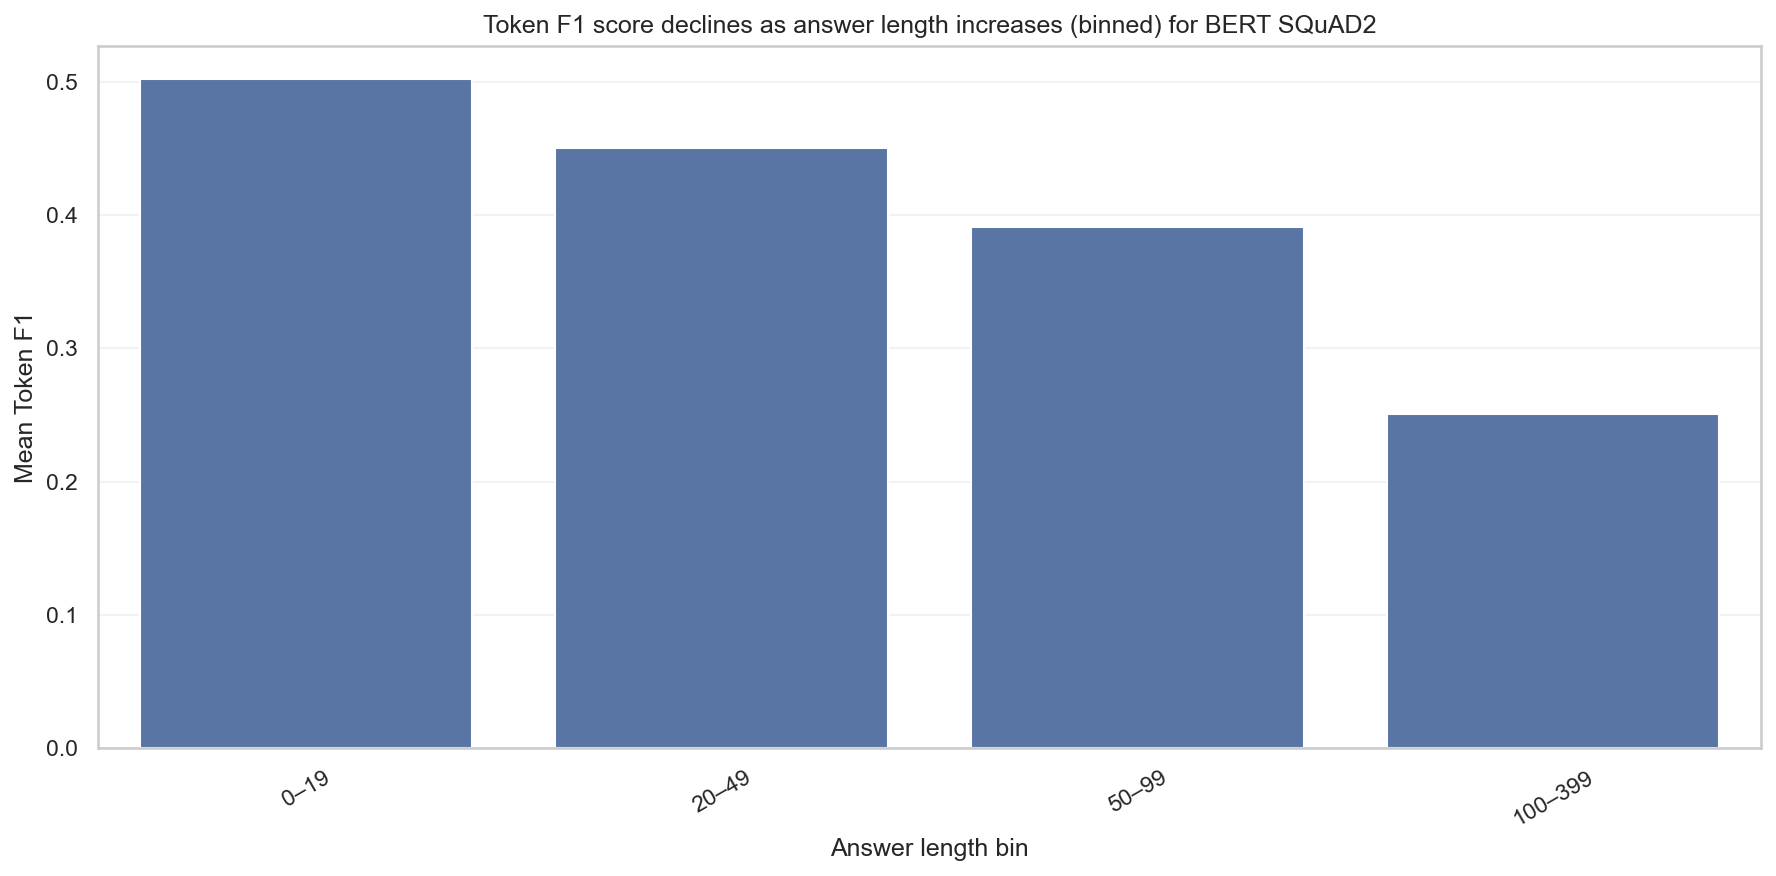

In [57]:
# Display decline in Token F1 scores as Answer Length increases, 
# with answer length binned and grouped

plot_token_f1_vs_answer_length_bin(
    qa_results,
    title="Token F1 score declines as answer length increases (binned) for BERT SQuAD2")

### 3.3 Fine-tuned BERT SQuAD2 model

To adapt the model to our domain, we finetune it using `AutoModelForQuestionAnswering`. The data is prepared using Hugging Face's `prepare_train_features` function<sup>14</sup>, which handles the tokenisation, sliding window chunking, and the mapping of character-level answer positions to token-level start and end positions. This last step is essential: the tokeniser splits words into subword tokens (e.g. "coastline" → "coast", "##line"), so the character offset must be remapped to the correct token index.

The model architecture adds two linear heads on top of BERT's hidden states: one predicting the start token position and one predicting the end token position. For each token in the sequence, the model outputs a score for how likely it is to be the start or end of the answer span. The predicted answer is the span between the highest-scoring start and end tokens.

Training loss showed a steady decline from 0.98 to 0.11 over 244 steps. The results after finetuning are:

Style | Token F1 Score |
--- | --- | 
Hard-Boiled | 0.96 |
For Children | 0.91 |
Descriptive | 0.41 |

These results are on the training data, so they don't indicate generalisability. What they do show is that even after extensive training, the model struggles with `descriptive` stories. Performance still declines with answer length, suggesting a structural limitation of extractive QA models: predicting both a start and end token becomes increasingly difficult as the span grows, because the model must correctly identify two positions rather than one, and longer spans have more plausible boundaries.

Key aspects of the model architecture are presented in a diagram below. Some key differences from the `base_bert` architecture in section 1.2 are:

1. The data is split into sliding windows with `max_length=384` and which overlap with `stride=128`.
2. Embeddings and the transformer layers function much the same.
3. The full set of hidden states are used instead of just the `[CLS]` token and they are passed through two separate linear layers to generate a 768-dimensional vector representing the start and end vectors. 
4. The output logits are converted into probabilities using softmax and the `argmax` function and the final prediction is the combined span of start and end tokens.

Note: The cross-entropy loss function is hidden for visual simplicity.

![image](bert_squad2_architecture.png)

In [58]:
# Load the tokeniser for BERT SQuAD2, tokenise the QA examples,
# split the stories into multiple sliding windows and identify
# the start and end positions of the answer labels

qa_tokenizer = AutoTokenizer.from_pretrained(QA_MODEL)

def prepare_train_features(examples):
    """Tokenize QA examples and compute start/end training labels."""
    tokenized_inputs = qa_tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=384,
        stride=128,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized_inputs.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized_inputs.pop("offset_mapping")

    tokenized_inputs["start_positions"] = []
    tokenized_inputs["end_positions"] = []

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized_inputs["input_ids"][i]
        cls_index = input_ids.index(qa_tokenizer.cls_token_id)

        sequence_ids = tokenized_inputs.sequence_ids(i)

        sample_index = sample_mapping[i]
        answer_start_char = examples["answer_start"][sample_index]
        answer_end_char = answer_start_char + len(examples["answer_text"][sample_index])

        token_start_index = 0
        while sequence_ids[token_start_index] != 1:
            token_start_index += 1

        token_end_index = len(input_ids) - 1
        while sequence_ids[token_end_index] != 1:
            token_end_index -= 1

        if not (offsets[token_start_index][0] <= answer_start_char and offsets[token_end_index][1] >= answer_end_char):
            tokenized_inputs["start_positions"].append(cls_index)
            tokenized_inputs["end_positions"].append(cls_index)
        else:
            while token_start_index < len(offsets) and offsets[token_start_index][0] <= answer_start_char:
                token_start_index += 1
            tokenized_inputs["start_positions"].append(token_start_index - 1)

            while offsets[token_end_index][1] >= answer_end_char:
                token_end_index -= 1
            tokenized_inputs["end_positions"].append(token_end_index + 1)

    return tokenized_inputs

In [59]:
# Map the answer text and answer start values to a nested dictionary in the answer column

qa_train_dataset = qa_dataset.map(
    lambda ex: {
        "answers": {
            "text": [ex["answer_text"]],
            "answer_start": [ex["answer_start"]],
        }
    }
)

print(qa_train_dataset)
print('\nSample record before tokenisation:')
qa_train_dataset[0]


Map:   0%|          | 0/648 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'question', 'context', 'answer_text', 'answer_start', 'style', 'answers'],
    num_rows: 648
})

Sample record before tokenisation:


{'id': '3_q1',
 'question': 'Where did she hide the message?',
 'context': "Beyond the frozen curve of a great river, beneath onion domes that glittered like scattered coins beneath a white tablecloth, there lay an old empire whose streets remembered the tread of kings and the whisper of dissent, a place of birch and brick where time gathered in thick snowdrifts and held its breath, and it was there that a lone natural philosopher, a maker of gears and glass and dangerous ideas, bent the world to his curiosity even as the world bent him back into a life of measured angles and long, patient experiments. He had the hands of a man who read the language of metal and the patience of one who listened to the slow counting of stars, and he had the concession of motion: an iron-framed chair with worn spokes that sighed like a clock whenever he pushed it, the wheelchair his constant companion as much as the glass prism on his desk that split sunlight into promises.\n\nIn the evenings, when the l

In [60]:
# Tokenise the data and return the answer start and end positions

qa_tokenized_train = qa_train_dataset.map(
    prepare_train_features,
    batched=True,
    remove_columns=qa_train_dataset.column_names,
)

print(qa_tokenized_train)
print('\nSample record after tokenisation:')
qa_tokenized_train[0]


Map:   0%|          | 0/648 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions'],
    num_rows: 1948
})

Sample record after tokenisation:


{'input_ids': [101,
  2073,
  2106,
  2016,
  5342,
  1996,
  4471,
  1029,
  102,
  3458,
  1996,
  7708,
  7774,
  1997,
  1037,
  2307,
  2314,
  1010,
  4218,
  20949,
  26193,
  2008,
  27566,
  2098,
  2066,
  7932,
  7824,
  4218,
  1037,
  2317,
  2795,
  23095,
  1010,
  2045,
  3913,
  2019,
  2214,
  3400,
  3005,
  4534,
  4622,
  1996,
  29449,
  1997,
  5465,
  1998,
  1996,
  7204,
  1997,
  24116,
  1010,
  1037,
  2173,
  1997,
  16421,
  1998,
  5318,
  2073,
  2051,
  5935,
  1999,
  4317,
  4586,
  13626,
  10128,
  3215,
  1998,
  2218,
  2049,
  3052,
  1010,
  1998,
  2009,
  2001,
  2045,
  2008,
  1037,
  10459,
  3019,
  9667,
  1010,
  1037,
  9338,
  1997,
  19456,
  1998,
  3221,
  1998,
  4795,
  4784,
  1010,
  6260,
  1996,
  2088,
  2000,
  2010,
  10628,
  2130,
  2004,
  1996,
  2088,
  6260,
  2032,
  2067,
  2046,
  1037,
  2166,
  1997,
  7594,
  12113,
  1998,
  2146,
  1010,
  5776,
  7885,
  1012,
  2002,
  2018,
  1996,
  2398,
  1997,
  1037,


In [61]:
# Finetune the BERT SQuAD2 model and display the results every 25 steps

finetuned_qa_model = AutoModelForQuestionAnswering.from_pretrained(QA_MODEL)

qa_training_args = TrainingArguments(
    output_dir="qa_domain_adaptation_outputs",
    overwrite_output_dir=True,
    per_device_train_batch_size=16, 
    learning_rate=3e-5,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=25,
    save_strategy="epoch",
    report_to="none",
    seed=STUDENT_SEED,
    bf16=True,
    dataloader_num_workers=0,
    dataloader_pin_memory=True
)

qa_trainer = Trainer(
    model=finetuned_qa_model,
    args=qa_training_args,
    train_dataset=qa_tokenized_train,
    processing_class=qa_tokenizer,
)

qa_train_result = qa_trainer.train()
print(qa_train_result)

Step,Training Loss
25,0.979600
50,0.402800
75,0.444200
100,0.345900
125,0.369800
150,0.133000
175,0.152100
200,0.178100
225,0.111600


TrainOutput(global_step=244, training_loss=0.33634574784607185, metrics={'train_runtime': 2234.9749, 'train_samples_per_second': 1.743, 'train_steps_per_second': 0.109, 'total_flos': 763509123182592.0, 'train_loss': 0.33634574784607185, 'epoch': 2.0})


In [62]:
# Save the trainign history and display the results

qa_log_history = pd.DataFrame(qa_trainer.state.log_history)
qa_log_history

,loss,grad_norm,learning_rate,epoch,step,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.9796,12.936522,0.000027,0.204918,25,NaN,NaN,NaN,NaN,NaN
1,0.4028,15.489381,0.000024,0.409836,50,NaN,NaN,NaN,NaN,NaN
2,0.4442,10.292011,0.000021,0.614754,75,NaN,NaN,NaN,NaN,NaN
3,0.3459,8.059896,0.000018,0.819672,100,NaN,NaN,NaN,NaN,NaN
4,0.3698,2.180187,0.000015,1.024590,125,NaN,NaN,NaN,NaN,NaN
5,0.1330,0.564951,0.000012,1.229508,150,NaN,NaN,NaN,NaN,NaN
6,0.1521,12.167213,0.000009,1.434426,175,NaN,NaN,NaN,NaN,NaN
7,0.1781,1.188023,0.000006,1.639344,200,NaN,NaN,NaN,NaN,NaN
8,0.1116,3.895171,0.000002,1.844262,225,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,2.000000,244,2234.9749,1.743,0.109,7.635091e+14,0.336346


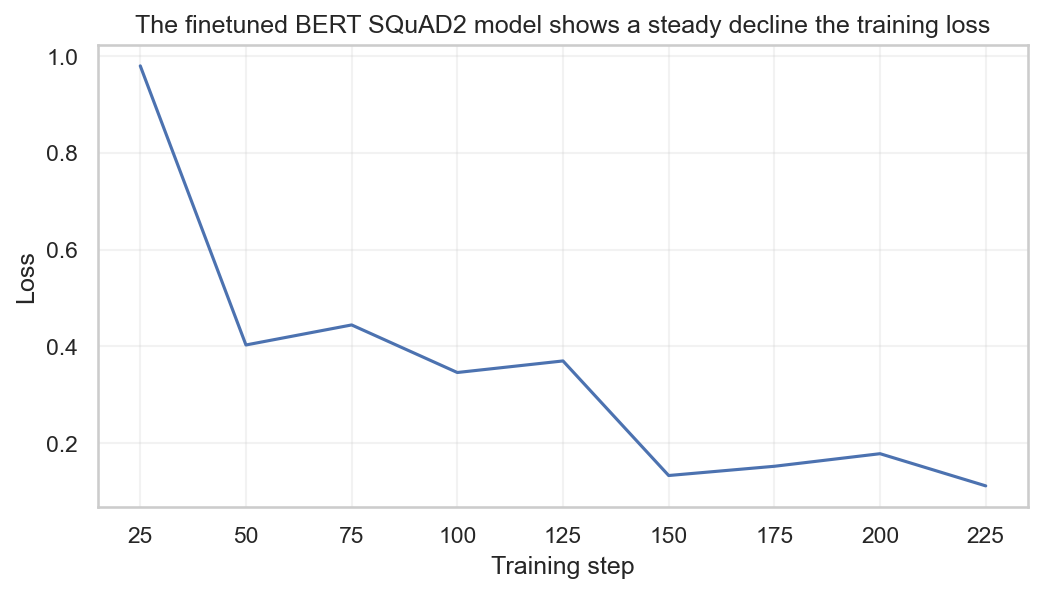

In [63]:
# Plot the training loss curve for the finetuned BERT SQuAD2 model

sns.lineplot(data=qa_log_history, x='step', y='loss')
plt.title("The finetuned BERT SQuAD2 model shows a steady decline the training loss")
plt.xlabel("Training step")
plt.ylabel("Loss");

In [64]:
# Run the pipeline for the finetuned QA model and display the results

finetuned_pipe = pipeline(
    "question-answering",
    model=finetuned_qa_model,
    tokenizer=qa_tokenizer,
    device=device_index,
)

finetuned_qa_results, finetuned_qa_overall, finetuned_qa_by_style = generate_qa_predictions(finetuned_pipe, qa_dataset)
finetuned_qa_results.head()

Device set to use cuda:0


,id,style,question,ground_truth_answer,predicted_answer,model_score,token_f1,answer_length
0,3_q1,descriptive,Where did she hide the message?,She hid the tiny gilded slip of paper inside t...,.,0.000251,0.000000,133
1,3_q2,descriptive,What did he do at the parapet?,He rolled his battered wheelchair to the parap...,He rolled his battered wheelchair to the parapet,0.004860,0.484848,147
2,5_q1,hard-boiled,What held the gate closed?,A rusted chain held the gate closed.,A rusted chain held the gate closed.,1.990366,1.000000,36
3,5_q2,hard-boiled,Where did he keep the kite?,He kept the kite in a drawer under the files.,He kept the kite in a drawer under the files.,0.896120,1.000000,45
4,8_q1,descriptive,What did he find half-buried beneath the sands...,He found a rake half-buried beneath the sandst...,He,0.000356,0.111111,95


In [65]:
# Display the overall results and aggregated by style for the finetuned QA model

print(finetuned_qa_overall)
finetuned_qa_by_style

{'token_f1': np.float64(0.7732789487422571), 'mean_model_score': np.float64(0.7769833331538313)}


,token_f1,model_score
style,,
hard-boiled,0.961186,1.160265
for children,0.911061,1.029140
descriptive,0.430932,0.113735


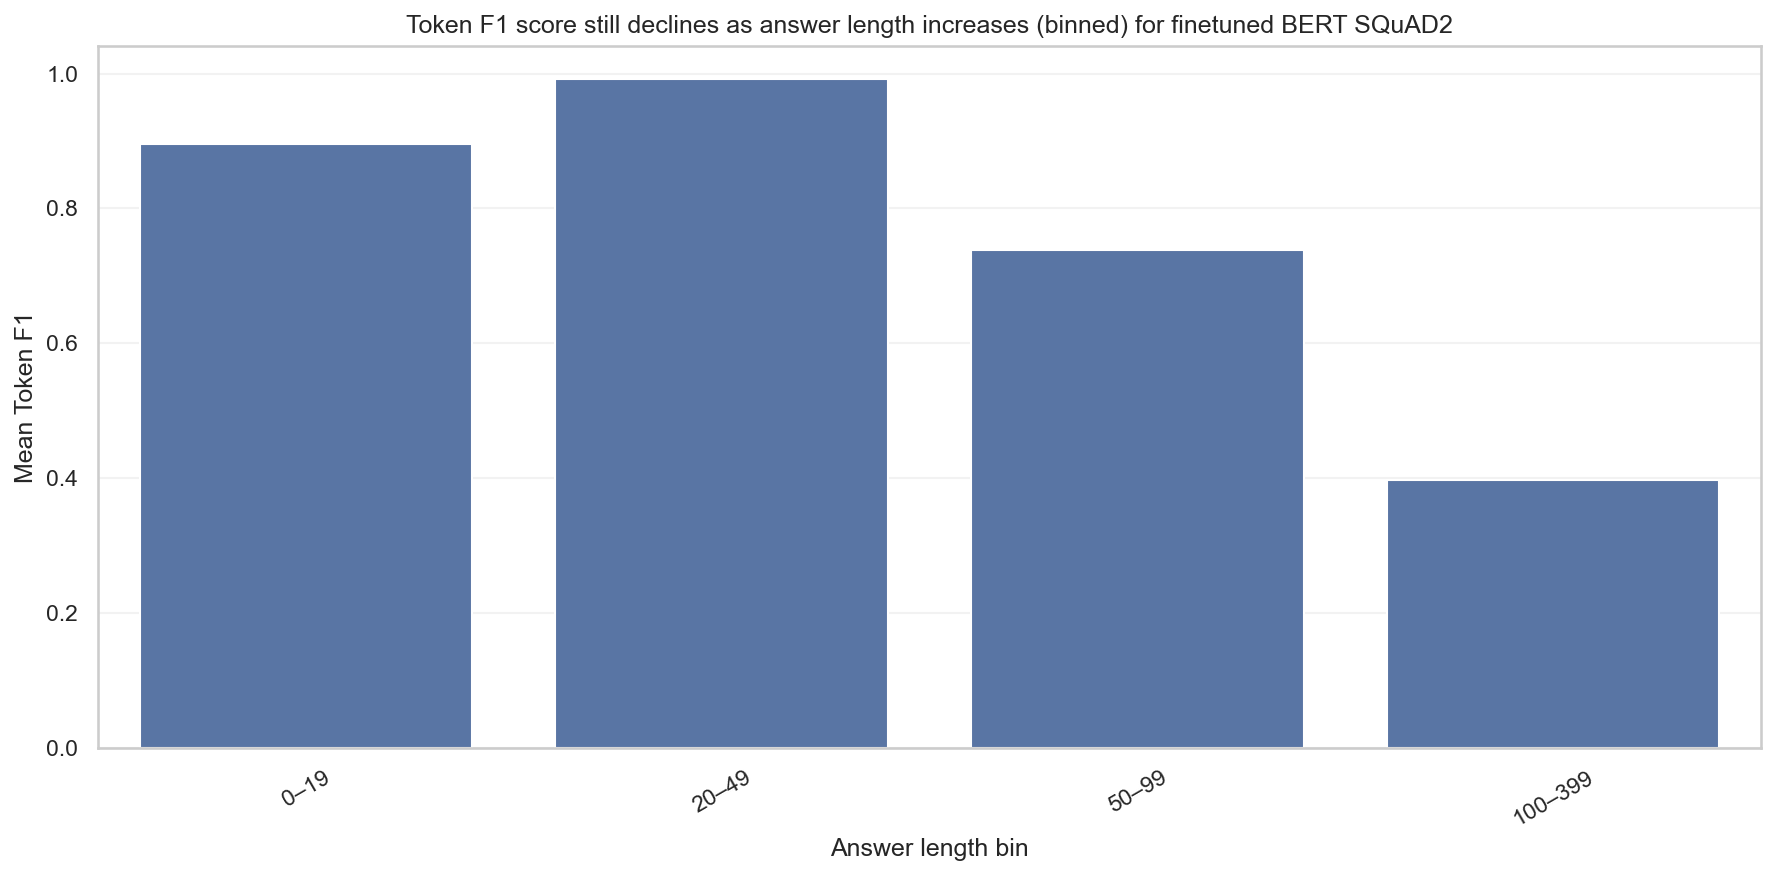

In [66]:
# Show that the token_f1 still declines with answer length for the finetuned model

plot_token_f1_vs_answer_length_bin(
    finetuned_qa_results, 
    title="Token F1 score still declines as answer length increases (binned) for finetuned BERT SQuAD2"
    )


## References

[1] Hugging Face, "LLM Course, Chapter 1: Encoder Models." [Online]. Available: https://huggingface.co/learn/llm-course/chapter1/6

[2] S. J. D. Prince, *Understanding Deep Learning*. MIT Press, 2023.

[3] T. Mikolov, K. Chen, G. Corrado, and J. Dean, "Efficient Estimation of Word Representations in Vector Space," *arXiv:1301.3781*, 2013.

[4] J. Devlin, M.-W. Chang, K. Lee, and K. Toutanova, "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding," in *Proc. NAACL*, 2019.

[5] N. Srivastava, G. Hinton, A. Krizhevsky, I. Sutskever, and R. Salakhutdinov, "Dropout: A Simple Way to Prevent Neural Networks from Overfitting," *J. Mach. Learn. Res.*, vol. 15, pp. 1929–1958, 2014.

[6] Cardiff NLP, "twitter-roberta-base-sentiment-latest," Hugging Face. [Online]. Available: https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest

[7] C. O. Alm, "Characteristics of High Agreement Affect Annotation in Text," in *Proc. Fourth Linguistic Annotation Workshop*, Uppsala, Sweden, Jul. 2010, pp. 118–122.

[8] SciPy developers, "scipy.stats.kruskal," *SciPy Documentation*. [Online]. Available: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html

[9] P. Ekman, "An Argument for Basic Emotions," *Cognition & Emotion*, vol. 6, no. 3–4, pp. 169–200, 1992.

[10] S. Mohammad, F. Bravo-Marquez, M. Salameh, and S. Kiritchenko, "SemEval-2018 Task 1: Affect in Tweets," in *Proc. SemEval*, 2018.

[11] R. Plutchik, "A General Psychoevolutionary Theory of Emotion," in *Emotion: Theory, Research, and Experience*, vol. 1, Academic Press, 1980.

[12] A. J. Reagan, L. Mitchell, D. Kiley, C. M. Danforth, and P. S. Dodds, "The Emotional Arcs of Stories are Dominated by Six Basic Shapes," *EPJ Data Sci.*, vol. 5, p. 31, 2016.

[13] P. Rajpurkar, R. Jia, and P. Liang, "Know What You Don't Know: Unanswerable Questions for SQuAD," in *Proc. ACL*, 2018.

[14] Hugging Face, "Question Answering," *Transformers Documentation*. [Online]. Available: https://huggingface.co/docs/transformers/tasks/question_answering

[15] L. Zheng *et al.*, "Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena," in *Proc. NeurIPS*, 2023.

[16] Deepset, "bert-base-uncased-squad2," Hugging Face. [Online]. Available: https://huggingface.co/deepset/bert-base-uncased-squad2


## Appendices

### Appendix 1: Country Keyword Counting

In [67]:
# Classify stories by simple substring keyword counting

# Define keywords
KEYWORDS_NI = ["north", "shore", "coast", "tid"] # tide or tidal
KEYWORDS_CHINA = ["silk", "rice", "porcelain", "lantern", "bamboo", "lotus"]
ALL_KEYWORDS = KEYWORDS_NI + KEYWORDS_CHINA

kw_df = country_df.copy()
kw_df_lower = kw_df["story"].str.lower()

# Count occurrences of each keyword per story
for kw in ALL_KEYWORDS:
    kw_df[kw] = kw_df_lower.str.count(kw)

kw_df['ni_score'] = kw_df[KEYWORDS_NI].sum(axis=1)
kw_df['china_score'] = kw_df[KEYWORDS_CHINA].sum(axis=1)
kw_df['is_ni'] = kw_df['ni_score'] > kw_df['china_score']

# Show the scores and predictions for each story
kw_df[['country', 'ni_score', 'china_score', 'is_ni']]

,country,ni_score,china_score,is_ni
0,Northern Ireland,2,0,True
1,China,1,2,False
2,Northern Ireland,4,0,True
3,Northern Ireland,4,0,True
4,China,0,0,False
...,...,...,...,...
283,Northern Ireland,0,0,False
284,China,0,4,False
285,Northern Ireland,0,0,False
286,Northern Ireland,9,0,True


In [68]:
# This achieves a 81% accuracy rating

ni_prediction_mean_by_country = kw_df.groupby('country')['is_ni'].mean()
ni_prediction_mean_by_country

country
China               0.194444
Northern Ireland    0.805556
Name: is_ni, dtype: float64

### Appendix 2: Hand-Drawn Basic BERT Architecture

![image](handdrawn_bert_architecture.png)

### Appendix 3: Sentiment Keywords

In [69]:
# Count the number of basic positive keywords to appear in stories 

# Define keywords
POSITIVE_KEYWORDS = ['happ', 'joy', 'celebrat']

positive_df = theme_df.copy()
kw_df_lower = positive_df["story"].str.lower()

# Count occurrences of each keyword per story
for kw in POSITIVE_KEYWORDS:
    positive_df[kw] = kw_df_lower.str.count(kw)

positive_df['positive_score'] = positive_df[POSITIVE_KEYWORDS].sum(axis=1)

positive_df.groupby('theme')['positive_score'].sum()

theme
a dangerous voyage         14
a mysterious conspiracy    10
love                       10
political rebellion        22
scientific discovery       33
Name: positive_score, dtype: int64

<Axes: xlabel='positive_score', ylabel='theme'>

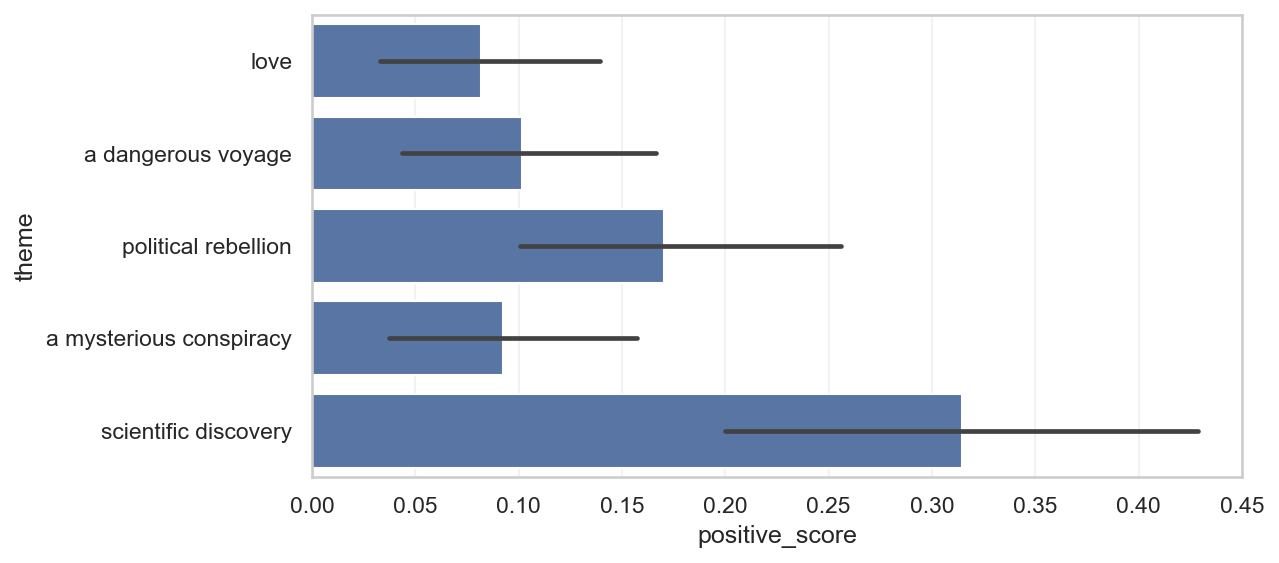

In [70]:
sns.barplot(positive_df, y='theme', x='positive_score')

In [ ]:
# AI declaration: 
# Gemini Deep Research was used to assist with the literature review up front
# Claude code was used to assist with the mermaid diagrams 
# and review markdown content after I'd written 4,000 words, bringing it back down to 3,000